# CS410 Project
Cindy Nguyen

Prof. Michael Wilson

TA. Amber Shore

CS410 TOP: Data With Python

1/17/2026

# Phase 1: Data Acquisition and Cleaning

## Project Overview
VocaDB is a fanmade wiki that contains all the information about VOCALOID, primarily songs and setlists for concerts around the world.

VOCALOID and its official concerts, along with special music events are owned and hosted by Crypton Future Media (CFM).

Although CFM has official concerts, there are also many fanmade events as well and other companies that host vocal synth concerts around the world.

VocaDB has an API which is where I'm getting my data from. I want to use this project to predict:
1. What songs will likely show up at the next VOCALOID concert in April (MIKU EXPO 2026)?
2. When will those songs play in the setlist? What is their average position?

## Importing VocaDB data from .json files
All of the data pulled from the API is stored in .json format. I created a .py script to pull all of this data from VocaDB, and formatted it a little nicer so it's easier to use/query from.

This is all of the songs from previous concert/event setlists.

In [244]:
import pandas as pd
import json

songs_df = pd.read_json("vocaloid_setlist_songs.json")
songs_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2274 entries, 0 to 2273
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              2274 non-null   str    
 1   english_title      2274 non-null   str    
 2   artist             2274 non-null   str    
 3   length_seconds     2274 non-null   int64  
 4   setlist_frequency  2274 non-null   int64  
 5   avg_setlist_order  2274 non-null   float64
 6   song_type          2274 non-null   str    
 7   pv_services        2274 non-null   str    
 8   times_favorited    2274 non-null   int64  
 9   rating             2274 non-null   int64  
dtypes: float64(1), int64(4), str(5)
memory usage: 177.8 KB


This looks pretty great! There's no `NaN` values at all, pretty much every field is populated so this cleaning step isn't necessary.

## Data Cleansing
Even if there are no `NaN` values, we still have to clean the data. And given that this is numerical data, cleaning it is sort of a different process.

### Computing the average setlist order (avg_setlist_order)
One of the data cleansing steps actually has to be done outside of Jupyter notebook since it has to do with how I retrieved my data and computed the average setlist order when creating the dataset itself.

VOCALOID is a big community of fans, full of very talented producers, musicians, and also DJs. This doesn't sound terrible until you realize that these special DJ events can go on for a really long time and mashup tons of songs together.

This is how long the setlist is for the MIKU EXPO Digital Stars 2021 Online event...

<img src="bad_data.png" alt="Image showing a setlist with 93 songs.">

93 songs is a LOT. Fortunately, "MONSTER" was only ever played once at this special event so it's not going to skew the data for other instances of it being played.

However, there were other songs that are much more popular that were in this setlist as well (Melt, Glass Wall, to name a few). These songs would typically show up much earlier in the setlist across multiple regular concerts, but are played much later at DJ events to build up excitement for the audience. 

This is a huge problem, since this will compute the average order to be much higher than it's supposed to be.

It's hard to demonstrate here, but what I'm going to do is exclude any setlists with > 50 songs from my dataset by modifying my Python script.

__**I can do this relatively safely for a few reasons**__:
1. From my own personal knowledge, most concerts average to around ~30 songs total
    - There are a couple exceptions:
       - Kikuoland (49)
       - Project SEKAI COLORFUL LIVE 4th - Unison (48)
       - VVV MUSIC LIVE concert series (~56)
2. Choosing the number "50" will cover the two main exceptions above, but exclude any super long special events (i.e. DJ sets) which are the MOST likely to skew the value of the average order negatively
3. It's safe to not include any of the VVV MUSIC LIVE concerts (or care at all about VVV MUSIC LIVE)
   - These concerts use voice/character models that would never show up at a MIKU EXPO concert due to licensing reasons UNLESS a major breakthrough happens where a collaboration is viable
      - Nowadays, this is incredibly rare, and in modern times has only happened ONCE with 32ki's song "Mesmerizer" where Kasane Teto made a guest appearance for the JAPAN LIVE TOUR 2025 ~ BLOOMING ~ (and this isn't even a main concert event!)
   - Even if any of the performers had a chance of appearing at MIKU EXPO (e.g. GUMI since she is partially licensed under CFM still), the songs from VVV MUSIC LIVE would never be performed at MIKU EXPO due to licensing reasons

### Before/After Results of Removing and Recalculating

#### Here is the dataset *before* removing all setlists longer than 50 tracks, along with the average positions computed including those long setlists.

In [245]:
songs_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2274 entries, 0 to 2273
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              2274 non-null   str    
 1   english_title      2274 non-null   str    
 2   artist             2274 non-null   str    
 3   length_seconds     2274 non-null   int64  
 4   setlist_frequency  2274 non-null   int64  
 5   avg_setlist_order  2274 non-null   float64
 6   song_type          2274 non-null   str    
 7   pv_services        2274 non-null   str    
 8   times_favorited    2274 non-null   int64  
 9   rating             2274 non-null   int64  
dtypes: float64(1), int64(4), str(5)
memory usage: 177.8 KB


In [246]:
# Setting this to 30 so we can actually see the avg_setlist_order be > 1

mask = songs_df["setlist_frequency"] > 30

frequent_songs = songs_df[mask]

frequent_songs

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
64,千本桜,A Thousand Cherry Blossoms,黒うさP feat. 初音ミク,246,37,14.270270,Original,"NicoNicoDouga, Youtube",388,1858
73,ルカルカ★ナイトフィーバー,Luka Luka★Night Fever,samfree feat. 巡音ルカ,239,39,16.307692,Original,"NicoNicoDouga, Youtube",261,1329
83,メルト,Melt,ryo feat. 初音ミク,256,41,24.292683,Original,"NicoNicoDouga, Youtube, SoundCloud",297,1522
149,リモコン,Remote Control,"じーざすP, WONDERFUL★OPPORTUNITY! feat. 鏡音リン, 鏡音レン",312,31,14.419355,Original,"NicoNicoDouga, Youtube",206,1086
152,ワールドイズマイン,World is Mine,"ryo, supercell feat. 初音ミク",255,62,13.500000,Original,"NicoNicoDouga, Youtube",303,1609
188,???,None,,0,75,19.946667,Other,Nothing,2,12
268,Tell Your World,None,kz feat. 初音ミク,257,66,19.045455,Remix,Youtube,218,1226


#### And here is the new dataset *after* removing setlists with more than 50 songs and recalculating the average positions.

In [247]:
clean_songs_df = pd.read_json("CLEAN_vocaloid_setlist_songs.json")

clean_songs_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2227 entries, 0 to 2226
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              2227 non-null   str    
 1   english_title      2227 non-null   str    
 2   artist             2227 non-null   str    
 3   length_seconds     2227 non-null   int64  
 4   setlist_frequency  2227 non-null   int64  
 5   avg_setlist_order  2227 non-null   float64
 6   song_type          2227 non-null   str    
 7   pv_services        2227 non-null   str    
 8   times_favorited    2227 non-null   int64  
 9   rating             2227 non-null   int64  
dtypes: float64(1), int64(4), str(5)
memory usage: 174.1 KB


In [248]:
# Setting this to 30 so we can actually see the avg_setlist_order be > 1

mask = clean_songs_df["setlist_frequency"] > 30

clean_frequent_songs = clean_songs_df[mask]

clean_frequent_songs

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
64,千本桜,A Thousand Cherry Blossoms,黒うさP feat. 初音ミク,246,36,12.361111,Original,"NicoNicoDouga, Youtube",388,1858
73,ルカルカ★ナイトフィーバー,Luka Luka★Night Fever,samfree feat. 巡音ルカ,239,39,16.307692,Original,"NicoNicoDouga, Youtube",261,1329
83,メルト,Melt,ryo feat. 初音ミク,256,41,24.292683,Original,"NicoNicoDouga, Youtube, SoundCloud",297,1522
149,リモコン,Remote Control,"じーざすP, WONDERFUL★OPPORTUNITY! feat. 鏡音リン, 鏡音レン",312,31,14.419355,Original,"NicoNicoDouga, Youtube",206,1086
152,ワールドイズマイン,World is Mine,"ryo, supercell feat. 初音ミク",255,62,13.500000,Original,"NicoNicoDouga, Youtube",303,1609
188,???,None,,0,65,13.784615,Other,Nothing,2,12
268,Tell Your World,None,kz feat. 初音ミク,257,65,18.169231,Remix,Youtube,218,1226


#### Results
If you're like me and couldn't tell the difference at first, here's a specific example using "Senbonzakura":

In [249]:
frequent_songs.head(1)

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
64,千本桜,A Thousand Cherry Blossoms,黒うさP feat. 初音ミク,246,37,14.27027,Original,"NicoNicoDouga, Youtube",388,1858


In [250]:
clean_frequent_songs.head(1)

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
64,千本桜,A Thousand Cherry Blossoms,黒うさP feat. 初音ミク,246,36,12.361111,Original,"NicoNicoDouga, Youtube",388,1858


The average setlist position changed! While that's only 2 spots earlier in the setlist for this particular song, that's still easily about 10 minutes of your life waiting for a fan favorite title to play.

2 spots isn't that big of a deal, but for other songs that are even more popular and were included in larger DJ setlists, the changes in the average setlist position could've been much more dramatic.

### Songs with 0 seconds in length

So you might've noticed something funky from the output earlier, and it's that there are songs that are 0 seconds in duration.

In [251]:
zero_length_songs = clean_songs_df["length_seconds"] == 0
clean_songs_df[zero_length_songs]

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
0,STARLIGHT,None,失いP feat. 花隈千冬,0,1,1.0,Cover,Nothing,0,0
5,物語の始まり,Monogatari no Hajimari,失いP feat. 花隈千冬,0,1,6.0,Cover,Nothing,0,0
9,ビーチストーリー,Beach Story,失いP feat. 京町セイカ AI,0,1,10.0,Cover,Nothing,0,0
10,黒いメガネ,Kuroi Megane,失いP feat. 花隈千冬,0,1,11.0,Cover,Nothing,0,0
11,僕の命,Boku no Inochi,失いP feat. 桜乃そら SV,0,1,12.0,Cover,Nothing,0,0
...,...,...,...,...,...,...,...,...,...,...
2147,地球毁灭的那一刻,When the doomsday comes,"KIDE, 动点P feat. 星尘",0,1,5.0,Original,Nothing,2,10
2182,All About That Bass,None,Dharma feat. 京町セイカ (Unknown),0,1,4.0,Cover,Nothing,1,3
2183,Feel Special,None,ぎゅや feat. 京町セイカ (Unknown),0,1,5.0,Cover,Nothing,0,0
2187,天城越え,Walk Over Amagi Pass,ぎゅや feat. 京町セイカ (Unknown),0,1,11.0,Cover,Nothing,0,0


This information is hidden and won't show up on the website, but according to VocaDB, one of these songs is *supposed* to be "FE!N" by Travis Scott.

<img src="fein.png" alt="Image showing database containing a song by Travis Scott, not Vocaloid.">

As funny as this is, no, CFM has never collaborated with Travis Scott and FE!N is definitely not a Japanese song.

I mentioned it earlier, but VocaDB is a fanmade wiki. And the "fanmade" parts of it really shine through in moments like this.

All humans make mistakes. Some of the mistakes can be incredibly funny (and intentional). Maybe someone's engaging in internet trolling to make my life more inconvenient. Though sometimes, human error and random things *just* happen. The other song titles seem very legitimate - and they are.

__**Theories as to why `0` second data happens**__:
- A fan is entering in bad data because they think it's funny (it kind of is (it's really inconvenient though))
- Someone entered the data incorrectly but forgot to remove the information from the database itself
- Some of the songs had actual durations but disappeared over time
   - "Monogatari no Hajimari" is supposed to be 4:27 (`267` seconds), but shows up as `0` because the original link to the song doesn't exist anymore (the artist deleted the song or the link to that song vanished for whatever reason)
- Artists delete their old works all the time, and it becomes lost media very quickly in the VOCALOID community to the point that there's a subcommunity that's dedicated to finding the origin of lost songs. If no one archives it, there's no trace of it existing other than basic information that might've been input into the database before it was deleted

Whatever the case may be, we don't really care. I care because I'm a fanatic, but for data processing, cleaning, and the sake of this project, we don't want this data! We're going to get rid of it!

In [252]:
# Drop all songs where their length in seconds is 0
# Only keep songs where their length is greater than 0
clean_songs_df = clean_songs_df.loc[clean_songs_df['length_seconds'] > 0]

clean_songs_df

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
1,Love is in Trouble -恋愛主義バージョン-,None,失いP feat. 弦巻マキ AI (Japanese),236,1,2.0,Cover,Youtube,3,13
2,HEADSTRONG -恋愛主義バージョン-,HEADSTRONG -Renai Shugi Version--,失いP feat. 京町セイカ AI,241,1,3.0,Cover,Youtube,1,5
3,精神疾患 -恋愛主義バージョン-,Mental Illness -Love Doctrine Version-,失いP feat. 夏色花梨,248,1,4.0,Cover,Youtube,4,14
4,愛をつかむ -恋愛主義バージョン-,Ai wo Tsukamu -Renai Shugi Version-,失いP feat. 小春六花 AI,311,1,5.0,Cover,Youtube,4,14
6,CAFETERIA -恋愛主義バージョン-,None,失いP feat. ついなちゃん AI,261,1,7.0,Cover,Youtube,3,11
...,...,...,...,...,...,...,...,...,...,...
2222,31 secrets,None,毎夜P feat. 重音テト,245,1,15.0,Original,Youtube,8,42
2223,ウルトラトレーラー,Ultra Trailer,マサラダ feat. 重音テトSV,272,1,16.0,Original,"NicoNicoDouga, Youtube, Bilibili",70,328
2224,吉原ラメント-再来盤-,Yoshiwara Lament -Re-recording-,亜沙 feat. 重音テトSV,224,1,17.0,Remaster,"NicoNicoDouga, Youtube",22,132
2225,優しくなれたら,Yasashikunaretara,亜沙 feat. 重音テトSV,202,1,18.0,Original,Youtube,2,12


In [253]:
clean_songs_df.info()

<class 'pandas.DataFrame'>
Index: 2099 entries, 1 to 2226
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              2099 non-null   str    
 1   english_title      2099 non-null   str    
 2   artist             2099 non-null   str    
 3   length_seconds     2099 non-null   int64  
 4   setlist_frequency  2099 non-null   int64  
 5   avg_setlist_order  2099 non-null   float64
 6   song_type          2099 non-null   str    
 7   pv_services        2099 non-null   str    
 8   times_favorited    2099 non-null   int64  
 9   rating             2099 non-null   int64  
dtypes: float64(1), int64(4), str(5)
memory usage: 180.4 KB


In [254]:
clean_songs_df.describe()

,length_seconds,setlist_frequency,avg_setlist_order,times_favorited,rating
count,2099.000000,2099.000000,2099.000000,2099.000000,2099.000000
mean,234.677465,2.441639,13.449130,29.928537,163.821820
std,79.100950,3.966350,9.764709,55.674499,280.739203
min,41.000000,1.000000,1.000000,0.000000,0.000000
25%,202.000000,1.000000,6.000000,2.000000,12.000000
50%,231.000000,1.000000,11.227273,8.000000,46.000000
75%,263.000000,2.000000,18.000000,30.000000,188.500000
max,2304.000000,65.000000,50.000000,648.000000,2985.000000


In [255]:
clean_songs_df.query('length_seconds == 41')

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
2048,またね,Till We Meet Again,"ryo, supercell feat. 初音ミク",41,1,41.0,Remaster,Youtube,11,55


We went from 2227 songs to 2099 songs, removing all 128 songs that were 0 seconds. Now we can see the shortest song is 41 seconds, which makes a lot more sense than a song that practically doesn't exist.

"またね" by ryo is meant to be an outro song and was played at the end of a concert. Concerts used to have outro songs like this one, but it's more likely nowadays that they play the instrumental of the concert theme to close out for the evening which isn't as easy to register into the database without causing duplicate data.

### Songs with no PV services -- Justifications

Some songs have been played at concerts but don't have any PV services. This means that it doesn't have a link to an original source (YouTube, SoundCloud, Spotify, Piapro, NicoNicoDouga, Bilibili, etc.)

There are quite a few of these actually.

In [256]:
no_pvs_list = clean_songs_df.query('pv_services == "Nothing"')
no_pvs_list.info()

<class 'pandas.DataFrame'>
Index: 49 entries, 205 to 2083
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              49 non-null     str    
 1   english_title      49 non-null     str    
 2   artist             49 non-null     str    
 3   length_seconds     49 non-null     int64  
 4   setlist_frequency  49 non-null     int64  
 5   avg_setlist_order  49 non-null     float64
 6   song_type          49 non-null     str    
 7   pv_services        49 non-null     str    
 8   times_favorited    49 non-null     int64  
 9   rating             49 non-null     int64  
dtypes: float64(1), int64(4), str(5)
memory usage: 4.2 KB


In [257]:
no_pvs_list.head(10)

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
205,风兮风兮,None,ilem feat. 洛天依 V4 (萌),216,1,8.0,Original,Nothing,2,10
250,Berlin Calling,None,"EHAMIC feat. 結月ゆかり, 石黒千尋",176,1,9.0,Cover,Nothing,0,0
251,月旅,Tsuki Tabi,GYARI feat. 結月ゆかり,282,1,14.0,Original,Nothing,2,10
294,香草茶与黑咖啡,Vanilla Tea and Black Coffee,"苏逸_Suyi, 动点P feat. 洛天依, 洛天依 V4 日本語 (Sweet)",202,1,2.0,Original,Nothing,1,7
382,セカイ,WORLD,Jordan Forester feat. 蒼姫ラピス,258,1,1.0,Cover,Nothing,0,0
383,ビーバー,None,Jordan Forester feat. 蒼姫ラピス,234,1,2.0,Cover,Nothing,0,0
384,ツギハギスタッカート,Patchwork Staccato,Jordan Forester feat. 蒼姫ラピス,251,1,3.0,Cover,Nothing,0,0
385,ジッタードール,Jitter Doll,Jordan Forester feat. 蒼姫ラピス,240,1,4.0,Cover,Nothing,0,0
386,p.h.,None,Jordan Forester feat. 蒼姫ラピス,156,1,5.0,Cover,Nothing,0,0
387,シャルル,Charles,Jordan Forester feat. 蒼姫ラピス,228,1,6.0,Cover,Nothing,0,2


A lot of these songs are covers that we can remove safely. However, there are a few originals, remixes, or remasters in there which we definitely want to keep.

__**We want to remove these covers that have no PV, but not *ALL* covers from the database for a few reasons**__:
1. It's possible that a popular VOCALOID song is *actually* a cover of an originally human song, but fans are simply unaware of it
   - If there is a song registered like this in the database, it would not be a good idea to remove a popular song simply because it's a cover. We want to see all possible songs that will show up, regardless of whether or not it's an original
2. Inspecting closely at the song titles, a vast majority of these songs without any PV are covers that could not be played at an official event due to licensing reasons
   - The list is relatively large (which is why I only display the first 10 entries), but one of the songs is "IDOL" which is originally produced by YOASOBI for the anime "Oshi no Ko". This would definitely NOT show up at a CFM-licensed concert
   - A vast majority of these song covers come from fan events where copyright/licensing isn't as strict, hence why it shows up here
3. You might notice a lot of the top entries are made by someone named "Jordan Forester" using "Aoki Lapis" as the voicebank. While all of their covers are fully VOCALOID songs that didn't originally have a human singer, fans still attribute a particular VOCALOID to be the "original singer"
   - "Patchwork Staccato" is originally sung by Hatsune Miku and has been performed multiple times across different concerts. However, only Miku herself would ever sing that song at an official event. Aoki Lapis would never show up to perform this track since it's not "her song" and the community does not associate her with it
   - A notable exception to this rule would be the Project Sekai concerts, where human-voiced game characters appear on stage and perform *with* the virtual singer. But these tracks are registered separately as a cover and have been performed very sparsely. These covers also have PV services because they're officially licensed by CFM, so they won't show up here

#### Other songs with no PVs

There's still the fact that while most of the no-PV songs are covers, that doesn't mean that all of them are.

There are a few other categories that show up:
- Original
- Remaster
- MusicPV
- Remix

In [258]:
no_pvs_list.query('song_type != "Cover"')

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
205,风兮风兮,None,ilem feat. 洛天依 V4 (萌),216,1,8.000000,Original,Nothing,2,10
251,月旅,Tsuki Tabi,GYARI feat. 結月ゆかり,282,1,14.000000,Original,Nothing,2,10
294,香草茶与黑咖啡,Vanilla Tea and Black Coffee,"苏逸_Suyi, 动点P feat. 洛天依, 洛天依 V4 日本語 (Sweet)",202,1,2.000000,Original,Nothing,1,7
469,シリョクケンサ,Eye Examination,40mP feat. GUMI,267,1,17.000000,Remaster,Nothing,2,8
477,Cross Road,None,19's Sound Factory feat. 初音ミク,238,1,6.000000,Original,Nothing,1,7
627,Fire◎Flower 2011,None,halyosy feat. 鏡音レン,262,1,21.000000,Remaster,Nothing,7,35
875,8102,None,COP feat. 洛天依 V4 (凝),276,1,9.000000,Original,Nothing,1,3
895,"Nostalogic [""M-E-I-K-O"" mix]",None,yuukiss feat. MEIKO,271,3,12.666667,Remaster,Nothing,4,18
1357,Tornado,None,Various artists,173,2,7.000000,MusicPV,Nothing,2,6
1654,Witness (Vocamerica Mix),Witness (Vocamerica Mix),EmpathP feat. DAINA,208,1,11.000000,Remix,Nothing,1,3


Rather than delete them anyway, my justification to remove or keep some of these tracks are a little bit different than the covers that have no PV services, and some of these cases are actually pretty odd that it's worth explaining what it is.

__**Extra notes before removal**__:

The lack of PV services implies that these songs are unreachable, undistributed anywhere else officially, and potentially unusable in future events. This may sound like a case of "remove everything", but I'll point out specific entries that I'm going to keep/remove.
1. Originals
   - __Original tracks I'm going to leave alone__ on the basis that it may appear in a concert again in the future even if the likelihood is low
      - It's more likely that these tracks will show up at a fan concert, and while I'm not necessarily interested in fan setlists, I am interested in predicting what may show up at the official MIKU EXPO. Fan concerts undeniably demonstrate what fans are interested in, and also show what trends and songs are popular at the time. CFM definitely accounts for fan behavior/fan favorites when creating events, so it's important to include
2. Remasters
   - __I'll be removing all remasters__ from this list **EXCEPT** for "Nostalogic"
      - "Fire◎Flower" is a popular song. However, "Fire◎Flower 2011" has only been played once. This is likely a remastered version produced privately just for that particular concert, that the chance of this audio track ever being reused is low
      - The same also applies to "Eye Examination" - a remastered version was made but never released officially
      - "Nostalogic ["M-E-I-K-O" mix]" I will keep for a couple of reasons:
         1. It has been played more than once
         2. There are multiple different versions of "Nostalogic" - various covers, remasters, remixes, and remasters of those remixes. It's an old and very iconic song for MEIKO, so there are many versions of it that have been redone over the years and the old versions of the song are still played at events. It's best not to remove it 
3. Remixes:
      - __I'll be removing all remixes__
      - "Witness (Vocamerica Mix)" is concert-specific to the VOCAMERICA fan concert series. While the original song is available and has PV services, this remix was only for a particular event in the series that it was never officially released
      - All of the remixes by "Colorful Palette feat. various" were for one of the Project Sekai live virtual concerts - in this particular case, they were for the "RESONANCE BEATS" event
         - These tracks are pretty interesting - there's not much information out there about it, but based on the extra notes for "DAYBREAK FRONTLINE" on the wiki, it seems like these remixes were just for this collaboration event between Leo/need and Vivid BAD SQUAD (two in-game music groups) and the remixes were never meant to be released officially anywhere after the event was over
4. MusicPVs
   - __I will remove "Tornado" from the list__
      - Trying to find what this is was kind of complicated. Essentially, it doesn't exist anymore so it should be removed
         - Full explanation: The PV doesn't exist on YouTube, but the song does (not on YouTube - it exists on NicoNicoDouga), but the song used in the PV was just a cover using Megurine Luka. The original song is better known as "Tatsumaki", and the original uses Hatsune Miku as the vocalist. However, the original Miku version was deleted, and the only one that exists now is the version that uses SF-A2 Miki

__**Extra information about China-specific tracks (and why I'm not removing them)**__:
   - "风兮风兮" ["The Wind The Wind"] is performed by Luo Tianyi, who is a Chinese virtual singer licensed by CFM. While this song may be popular in China and might play at a lot of her China-specific concerts, we have no easy way of finding this information and confirming
   - Due to China's strict internet rules and the fact that Bilibili is not easily accessible outside of China, this information often never gets reuploaded or discussed on the western side of the fandom
   - While it's unlikely that Luo Tianyi or other Chinese virtual idols would perform in America, because they are officially licensed by CFM who hosts MIKU EXPO, there is technically always a non-zero chance that any of them could appear at an event
      - Hatsune Miku and Luo Tianyi have actually performed together multiple times in the past in China, and given that they both have a great relationship with the Chinese fans, it wouldn't be surprising if Luo Tianyi made a surprise appearance at some point in America
   


### Songs with no PV Services -- ACTUAL REMOVAL STEPS (pt 1.)

I spent an entire section justifying what should and shouldn't be removed. I'm fully aware it's incredibly long, and I'm sorry. Anyways, now I'll actually clean up the data.

To recap an incredibly long section...

__**We want to remove**__:
- All covers with no PVs
- All remixes with no PVs
- "Fire◎Flower 2011"
- "シリョクケンサ"/"Eye Examination"
- "Tornado" Music PV

__**We want to keep**__:
- Original tracks
- "Nostalogic ["M-E-I-K-O" mix]"
- Chinese-specific tracks (covered by keeping all originals)

In [259]:
# I'm going to create a temporary dataframe that holds all the entries I want to remove
to_remove_no_pv_items = no_pvs_list.copy()

### Excluding from the list entries we want to keep ### 
# Exclude all originals as we want to keep these
to_remove_no_pv_items = to_remove_no_pv_items.query('song_type != "Original"')

# We want to exclude "Nostalogic ["M-E-I-K-O" mix]"
to_remove_no_pv_items = to_remove_no_pv_items.query('title != \'Nostalogic ["M-E-I-K-O" mix]\'')

#### Here is our list of items that we want to remove:

In [260]:
# Display the list just to confirm we're not going to remove the wrong information

to_remove_no_pv_items.head(5)

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
250,Berlin Calling,None,"EHAMIC feat. 結月ゆかり, 石黒千尋",176,1,9.0,Cover,Nothing,0,0
382,セカイ,WORLD,Jordan Forester feat. 蒼姫ラピス,258,1,1.0,Cover,Nothing,0,0
383,ビーバー,None,Jordan Forester feat. 蒼姫ラピス,234,1,2.0,Cover,Nothing,0,0
384,ツギハギスタッカート,Patchwork Staccato,Jordan Forester feat. 蒼姫ラピス,251,1,3.0,Cover,Nothing,0,0
385,ジッタードール,Jitter Doll,Jordan Forester feat. 蒼姫ラピス,240,1,4.0,Cover,Nothing,0,0


In [261]:
# And also show that it's not JUST covers in here - remasters, remixes, and music PVs are also included in here to be removed
to_remove_no_pv_items.query('song_type != "Cover"')

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
469,シリョクケンサ,Eye Examination,40mP feat. GUMI,267,1,17.0,Remaster,Nothing,2,8
627,Fire◎Flower 2011,None,halyosy feat. 鏡音レン,262,1,21.0,Remaster,Nothing,7,35
1357,Tornado,None,Various artists,173,2,7.0,MusicPV,Nothing,2,6
1654,Witness (Vocamerica Mix),Witness (Vocamerica Mix),EmpathP feat. DAINA,208,1,11.0,Remix,Nothing,1,3
1876,Blessing,None,Colorful Palette feat. various,277,1,10.0,Remix,Nothing,0,2
1882,ヒバナ -Reloaded-,HIBANA -Reloaded-,Colorful Palette feat. various,204,1,9.0,Remix,Nothing,1,5
1883,DAYBREAK FRONTLINE,None,Colorful Palette feat. various,205,1,10.0,Remix,Nothing,2,8
1884,NEO,None,Colorful Palette feat. various,185,1,11.0,Remix,Nothing,1,3


In [262]:
# There are 39 songs that we want to remove from our actual dataframe
to_remove_no_pv_items.info()

<class 'pandas.DataFrame'>
Index: 39 entries, 250 to 1884
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              39 non-null     str    
 1   english_title      39 non-null     str    
 2   artist             39 non-null     str    
 3   length_seconds     39 non-null     int64  
 4   setlist_frequency  39 non-null     int64  
 5   avg_setlist_order  39 non-null     float64
 6   song_type          39 non-null     str    
 7   pv_services        39 non-null     str    
 8   times_favorited    39 non-null     int64  
 9   rating             39 non-null     int64  
dtypes: float64(1), int64(4), str(5)
memory usage: 3.4 KB


#### Songs with no PV Services -- ACTUAL REMOVAL STEPS (pt. 2)
Now that we have our list of items to remove, we need to remove it from the actual database entirely.

In [263]:
# Check to see what songs are on the "no fly" list in our main dataframe, store it in a new dataframe
condition = clean_songs_df.isin(to_remove_no_pv_items)

# Anything with all True values is a perfect match to the entries we want to remove and should be obliterated on sight
#condition

# Create a new dataframe - this should hold ALL songs but exclude the 39 items on the remove list
all_clean_songs_df = clean_songs_df.drop(to_remove_no_pv_items[condition].index)

all_clean_songs_df.count()

title                2060
english_title        2060
artist               2060
length_seconds       2060
setlist_frequency    2060
avg_setlist_order    2060
song_type            2060
pv_services          2060
times_favorited      2060
rating               2060
dtype: int64

In [264]:
# We can compare the count to the original dataframe we were working with and confirm that the 39 entries are gone
clean_songs_df.count()

title                2099
english_title        2099
artist               2099
length_seconds       2099
setlist_frequency    2099
avg_setlist_order    2099
song_type            2099
pv_services          2099
times_favorited      2099
rating               2099
dtype: int64

In [265]:
# Another way to confirm is to check if any of the removal list items are in the new dataframe at all using the isin() method
# The entire dataframe is False so I'm going to use head() to truncate the output
to_remove_no_pv_items.isin(all_clean_songs_df).head()

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
250,False,False,False,False,False,False,False,False,False,False
382,False,False,False,False,False,False,False,False,False,False
383,False,False,False,False,False,False,False,False,False,False
384,False,False,False,False,False,False,False,False,False,False
385,False,False,False,False,False,False,False,False,False,False


## Final Results
Between all of the data cleansing, justifications, and mini VOCALOID history + culture lessons, here is our final dataset.

__**Recap on Data Cleanse**__:
- Fixed the average setlist order being calculated with bad data
   - Readjusted my Python script to not include setlists larger than 50 as to not corrupt the dataset
   - Recalculated the average setlist order after excluding these setlists so the average turns out the way we expect it to 
- Removed all songs `0` seconds in length
- Removed all covers + remixes with no PV services, while keeping some entries due to circumstance/history

In [266]:
# Print the dataset one last time to demonstrate the results

all_clean_songs_df

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
1,Love is in Trouble -恋愛主義バージョン-,None,失いP feat. 弦巻マキ AI (Japanese),236,1,2.0,Cover,Youtube,3,13
2,HEADSTRONG -恋愛主義バージョン-,HEADSTRONG -Renai Shugi Version--,失いP feat. 京町セイカ AI,241,1,3.0,Cover,Youtube,1,5
3,精神疾患 -恋愛主義バージョン-,Mental Illness -Love Doctrine Version-,失いP feat. 夏色花梨,248,1,4.0,Cover,Youtube,4,14
4,愛をつかむ -恋愛主義バージョン-,Ai wo Tsukamu -Renai Shugi Version-,失いP feat. 小春六花 AI,311,1,5.0,Cover,Youtube,4,14
6,CAFETERIA -恋愛主義バージョン-,None,失いP feat. ついなちゃん AI,261,1,7.0,Cover,Youtube,3,11
...,...,...,...,...,...,...,...,...,...,...
2222,31 secrets,None,毎夜P feat. 重音テト,245,1,15.0,Original,Youtube,8,42
2223,ウルトラトレーラー,Ultra Trailer,マサラダ feat. 重音テトSV,272,1,16.0,Original,"NicoNicoDouga, Youtube, Bilibili",70,328
2224,吉原ラメント-再来盤-,Yoshiwara Lament -Re-recording-,亜沙 feat. 重音テトSV,224,1,17.0,Remaster,"NicoNicoDouga, Youtube",22,132
2225,優しくなれたら,Yasashikunaretara,亜沙 feat. 重音テトSV,202,1,18.0,Original,Youtube,2,12


<p style="text-align: center; font-size: 50px;" >Thank you!</p>


<center><img src="https://media1.tenor.com/m/ob9OW4ULA7kAAAAC/hatsune-miku-hatsune.gif" alt="GIF of Hatsune Miku from 'World Is Mine' MV, looking tired and slowly deflating until her face is off-screen."></center>


<p style="text-align: center; font-size: 12px;" >I'm tired... time for a break...</p>

# Phase 2: Exploratory Data Analysis (EDA)

## Overview
Now that we've handled getting our data and the big primary cleaning steps, let's continue!

We now have our cleaned-up dataframe. I'll display it again below just to confirm it still exists, but now that we have it we want to start visualizing our data.

In [267]:
# Display all_clean_songs_df to confirm its existence
all_clean_songs_df

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
1,Love is in Trouble -恋愛主義バージョン-,None,失いP feat. 弦巻マキ AI (Japanese),236,1,2.0,Cover,Youtube,3,13
2,HEADSTRONG -恋愛主義バージョン-,HEADSTRONG -Renai Shugi Version--,失いP feat. 京町セイカ AI,241,1,3.0,Cover,Youtube,1,5
3,精神疾患 -恋愛主義バージョン-,Mental Illness -Love Doctrine Version-,失いP feat. 夏色花梨,248,1,4.0,Cover,Youtube,4,14
4,愛をつかむ -恋愛主義バージョン-,Ai wo Tsukamu -Renai Shugi Version-,失いP feat. 小春六花 AI,311,1,5.0,Cover,Youtube,4,14
6,CAFETERIA -恋愛主義バージョン-,None,失いP feat. ついなちゃん AI,261,1,7.0,Cover,Youtube,3,11
...,...,...,...,...,...,...,...,...,...,...
2222,31 secrets,None,毎夜P feat. 重音テト,245,1,15.0,Original,Youtube,8,42
2223,ウルトラトレーラー,Ultra Trailer,マサラダ feat. 重音テトSV,272,1,16.0,Original,"NicoNicoDouga, Youtube, Bilibili",70,328
2224,吉原ラメント-再来盤-,Yoshiwara Lament -Re-recording-,亜沙 feat. 重音テトSV,224,1,17.0,Remaster,"NicoNicoDouga, Youtube",22,132
2225,優しくなれたら,Yasashikunaretara,亜沙 feat. 重音テトSV,202,1,18.0,Original,Youtube,2,12


## Data Visualizations

I'll be using seaborn and matplotlib to create all of my data visuals.

In [268]:
import seaborn as sns
import matplotlib.pyplot as plt

### Graphing Songs Based On Length

Music is music - there are all kinds of different genres, artists, languages, but universally they all share one thing in common: all songs must have some sort of length.

This database has a lot of songs, and we can plot that into a histogram to see what time amounts are the most common. I also use a rug plot to show how clustered/dispersed the songs are in length.

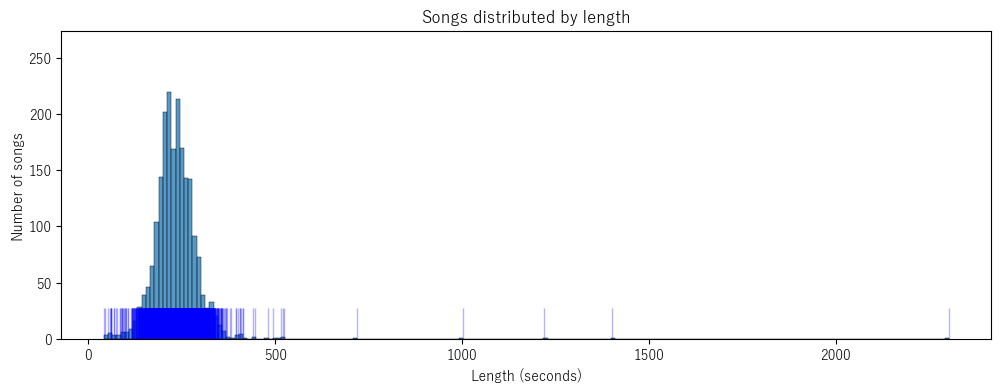

In [269]:
# Create figure
plt.figure(figsize=(12,4))

# Create histogram chart
sns.histplot(data=all_clean_songs_df, x="length_seconds", bins=200)

# Create rug plot to show dispersion of data
sns.rugplot(all_clean_songs_df['length_seconds'], height=0.1, color='blue', alpha=0.3)

plt.title("Songs distributed by length")
plt.xlabel("Length (seconds)")
plt.ylabel("Number of songs")

plt.show()

In [270]:
all_clean_songs_df[all_clean_songs_df["length_seconds"] > 600]

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
254,ボーカロイドたちがただﾃｯﾃｰﾃﾚｯﾃｰするだけ,Vocaloids just do tettey-terettey only,GYARI feat. various,1219,1,19.0,Original,"NicoNicoDouga, Youtube",29,157
672,ボーカロイドたちがただ叫ぶだけ,Vocaloids yelling only,"GYARI feat. 鏡音リン, 鏡音レン",1401,1,23.0,Original,"NicoNicoDouga, Youtube",38,191
784,"Sight, Noise, Life and the Earth",None,きくお feat. 初音ミク V3 (English),2304,1,21.0,Original,"Youtube, Bandcamp",19,105
1587,Alice in Musicland,None,OSTER project feat. various,718,2,14.5,Original,"NicoNicoDouga, Youtube",46,250
2067,천 년의 시,Poem of a Thousand Years,상록수 feat. SeeU (Korean),1002,1,20.0,Original,"NicoNicoDouga, Youtube, Bandcamp",14,62


#### What are those outliers?

Over 2000 minutes is absurd and I'm fully aware of this. The longest song is "Sight, Noise, Life and the Earth" by Kikuo, which at 2304 seconds is ~38.4 minutes.

I was really worried that I didn't clean the data thoroughly enough and only noticed something crazy now, but actually, it's perfectly fine that these exist. They've only been played once or twice at concerts, and it's much more likely that during the concerts themselves only a small fraction of the full songs were played. With the way VocaDB enters information, the database doesn't tell us or give us much warning if this is the case, but it's safe to assume so. I would hope a 30 minute song *wouldn't* be playing during a concert.

These are also real songs (yes, even "Vocaloids yelling only" or the other one by GYARI. It's really good!), and if they were played at a concert at one point that does show some level of interest in those titles.

Either way, I won't remove it from the data. What I am going to do is remake the same graph, but limit the range of what we're looking at to temporarily ignore these outliers without deleting them entirely from our dataframe.

__**This feels like I'm creating misleading graphics, but I'll try to justify why this is okay**__:
- These outliers have no chance of appearing at an official MIKU EXPO due to the nature of the songs being way too long
- The songs in this list likely wouldn't appear at a MIKU EXPO due to the content of the songs
   - Kikuo's music is disturbing and not kid-friendly (CFM often avoids playing songs that are too explicit)
   - GYARI's music is jazzy and has no lyrics so this isn't concert-friendly
   - Any song with SeeU won't play at MIKU EXPO since she's Korean, a retired voicebank, and there was controversy in 2014 regarding her voice provider (Dahee from K-pop girl group "GLAM")
- However, deleting these songs entirely could negatively impact the information/overall consistency in our data
   - Just because it's likely doesn't guarantee that these artists *can't* show up at an official CFM concert/event of any kind
   - OSTER project music has been played multiple times across different events
   - With my dataset I've decided earlier on that I'm not segregating the data between official/fan events because fan events show community interest, so removing these entries would cause the data to be inconsistent (and not to mention, this would be a very difficult task when there's no way to really tell what is an official event and what isn't in the database) 

Here's the adjusted graphic below to focus primarily on where most of the data is, ignoring the outliers without removing them from our data:

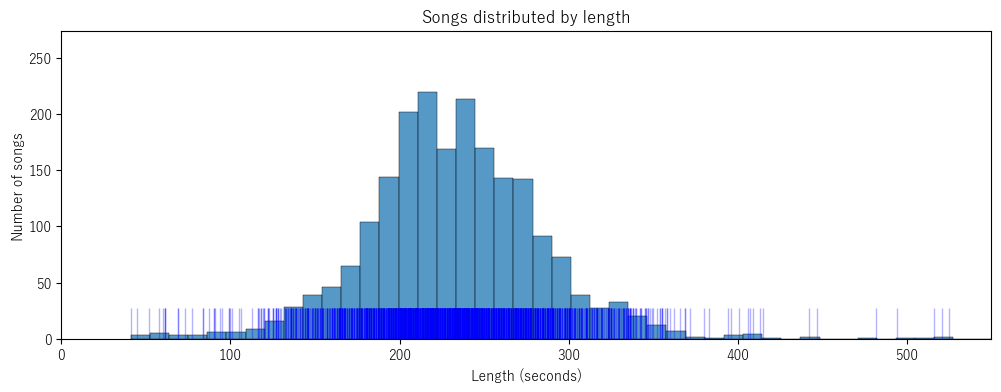

In [271]:
# Create the figure
plt.figure(figsize=(12,4))

# Create the histogram
sns.histplot(data=all_clean_songs_df, x="length_seconds", bins=200)

# Create the rug plot to show the concentrations of data
sns.rugplot(all_clean_songs_df['length_seconds'], height=0.1, color='blue', alpha=0.3)

# Limit the diagram up to 550 seconds to include the data we need and exclude the outliers
plt.xlim(0, 550)

plt.title("Songs distributed by length")
plt.xlabel("Length (seconds)")
plt.ylabel("Number of songs")

plt.show()

After condensing the results and focusing only up to 550 seconds, we can see a lot of the songs are somewhere between ~170-300 seconds.

This makes sense - most concert songs would be around this length to encourage fan participation and allow fans to enjoy the music without each track feeling too short or too long.

### Heat Maps to Demonstrate Correlation

As an older VOCALOID fan, it's really easy for me to say "if a song is more popular, obviously it's more likely to play at a concert!" I mean, it makes sense, right? If a song is more popular, naturally the fans are more likely to want to see it live. This project was maybe the first time I had to really think "wait, is that actually true?" Intuitively and with what I know, it is true, but let's actually prove it so I'm not lying and spreading fake fandom news.

A great way to visualize correlations between numerical data is by using heat maps.

Text(0.5, 1.0, 'Correlation Between Numerical Data Members Across VocaDB')

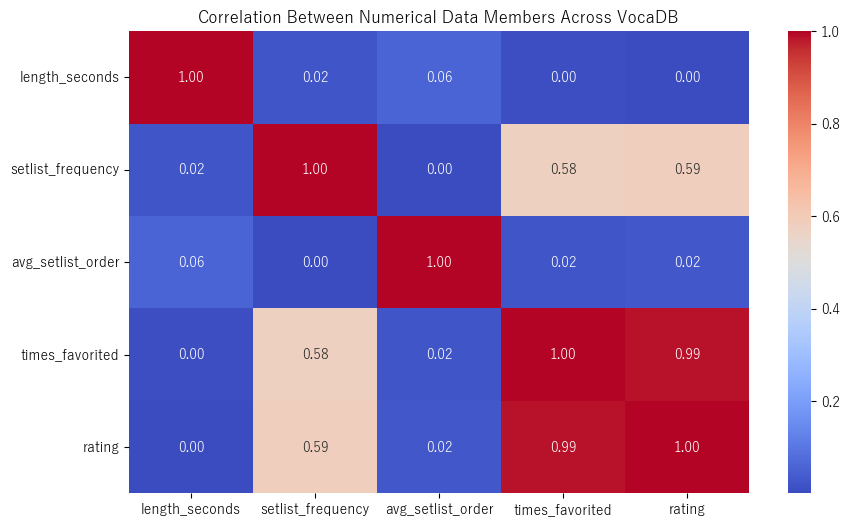

In [272]:
# Create the figure
plt.figure(figsize=(10,6))

# Create a correlation matrix for the songs
song_corr_matrix = all_clean_songs_df.corr(numeric_only=True)

# Make the figure a heat map
sns.heatmap(data=song_corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Between Numerical Data Members Across VocaDB")

This is simply *fascinating*. This is actual proof that there is a correlation between how popular a song is compared to how frequently it's been played at concerts in the past. Initially, I was expecting it to be not much, but 0.58-0.59 is a relatively undeniable correlation between the two and much higher than I expected!

It may have seemed pretty obvious, but I wasn't sure if `times_favorited` and `rating` were related to each other. On the website, `rating` seems pretty arbitrary in how it's calculated, but it's good to know that they're very similar and that it's highly likely that the number of `times_favorited` informs the value of a song's `rating`.

With this kind of knowledge, it'll be easier to predict what could play at the next MIKU EXPO, but I also want to point out that this map also demonstrates what songs the fandom really values. What songs fans care about, what songs they really like, iconic hits, nostalgic tunes... which songs continue to persist as time passes and as trends change? VOCALOID is a very vast community, and seeing that there still are community favorites despite how large and old the fanbase has become is very touching.

### PV Services and Popularity
#### Some history about PV services and why there are so many

This is going to be a long one. Just know that "PV" stands for "promotional video".

At the start of VOCALOID and it's conception, it was a niche and obscure thing. No one really knew what it was - an anime character from some TV show? An instrument? A robot? How human is it? Is it human at all? Even now, people who are new to the concept of vocal synths ponder the same questions and in some ways, it is still a niche community (at least, in terms of the technology that VOCALOIDs use).

Before the age of generative AI and fake AI voice models, all we had were simple consonant-vowel vocal synths such as these. We had no clue they would take the world by storm and be able to perform live concerts years later. But during its humble beginnings, a small community was surely forming around these virtual idols, and it began (mostly) on NicoNicoDouga. 

NicoNicoDouga (NND) is Japan's version of YouTube. YouTube wasn't banned nor was it restricted in Japan, but NND was more commonly used. Its early days are remembered for having a lot of creative content related to fandoms, and the website was where the primary VOCALOID community was during the late 2000's and early 2010's.

As VOCALOID grew, so did its fanbase. Soon, VOCALOID was becoming popular in America that songs were redistributed from NND to YouTube, and YouTube slowly became the main place to view, distribute songs, and interact with the fandom as a whole. Nowadays, VOCALOID is popular across multiple social media platforms and there are many places to listen to the music.

But enough history, let's move on to the data.

#### Data Explosions and Strange Calculations

As mentioned above, there are a lot of PV services you can use to listen to VOCALOID music nowadays even if historically, it all really began on NND.

I want to know a couple things about the different PV services that the fandom uses:
1. Which PV services have the highest average song rating?
2. Which PV services are used, and which ones have been used the most?

In [273]:
all_clean_songs_df.tail(5)

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
2222,31 secrets,None,毎夜P feat. 重音テト,245,1,15.0,Original,Youtube,8,42
2223,ウルトラトレーラー,Ultra Trailer,マサラダ feat. 重音テトSV,272,1,16.0,Original,"NicoNicoDouga, Youtube, Bilibili",70,328
2224,吉原ラメント-再来盤-,Yoshiwara Lament -Re-recording-,亜沙 feat. 重音テトSV,224,1,17.0,Remaster,"NicoNicoDouga, Youtube",22,132
2225,優しくなれたら,Yasashikunaretara,亜沙 feat. 重音テトSV,202,1,18.0,Original,Youtube,2,12
2226,ODDS & ENDS（テトライブ2025-実演盤-）,ODDS & ENDS (Teto Live 2025 -Live Arrange-),"亜沙, 村田祐一, ASIAN WAVE feat. 重音テトSV",347,1,19.0,Remix,Youtube,1,5


You may see something funky here, and it's that some of the values in "pv_services" are a comma-separated list of names. Normally, most people wouldn't think much of it, but when it comes to dealing with data directly it's kind of awful.

It sounds hilarious but we're going to have to explode (***boom***) our data.

We need to split up these comma-separated lists and have each PV service have its own individual song listing so we can count all the occurrences of each service accurately.

In [274]:
# Make a copy of the original dataframe
exploded_songs = all_clean_songs_df.copy()

# exploded_songs is an exact copy of all_clean_songs_df
# We now want to split up those comma-separated lists and split based on the commas
exploded_songs['pv_services'] = all_clean_songs_df['pv_services'].str.split(",")

# We now EXPLODE!!! For each song, there will now be extra entries if there are multiple PV services provided
exploded_songs = exploded_songs.explode('pv_services')

# Because of the way we split the lists earlier, we will have trailing whitespace. Remove using strip()
exploded_songs['pv_services'] = exploded_songs['pv_services'].str.strip()

exploded_songs.tail(10)

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
2221,好きな惣菜発表ドラゴン,Favorite-Daily-Dish-Announcing Dragon,ンバヂ feat. 重音テト,122,1,14.0,Original,Youtube,12,66
2221,好きな惣菜発表ドラゴン,Favorite-Daily-Dish-Announcing Dragon,ンバヂ feat. 重音テト,122,1,14.0,Original,Bilibili,12,66
2222,31 secrets,None,毎夜P feat. 重音テト,245,1,15.0,Original,Youtube,8,42
2223,ウルトラトレーラー,Ultra Trailer,マサラダ feat. 重音テトSV,272,1,16.0,Original,NicoNicoDouga,70,328
2223,ウルトラトレーラー,Ultra Trailer,マサラダ feat. 重音テトSV,272,1,16.0,Original,Youtube,70,328
2223,ウルトラトレーラー,Ultra Trailer,マサラダ feat. 重音テトSV,272,1,16.0,Original,Bilibili,70,328
2224,吉原ラメント-再来盤-,Yoshiwara Lament -Re-recording-,亜沙 feat. 重音テトSV,224,1,17.0,Remaster,NicoNicoDouga,22,132
2224,吉原ラメント-再来盤-,Yoshiwara Lament -Re-recording-,亜沙 feat. 重音テトSV,224,1,17.0,Remaster,Youtube,22,132
2225,優しくなれたら,Yasashikunaretara,亜沙 feat. 重音テトSV,202,1,18.0,Original,Youtube,2,12
2226,ODDS & ENDS（テトライブ2025-実演盤-）,ODDS & ENDS (Teto Live 2025 -Live Arrange-),"亜沙, 村田祐一, ASIAN WAVE feat. 重音テトSV",347,1,19.0,Remix,Youtube,1,5


As you can see, for any songs that have multiple PV services they are now listed multiple times with the PV services listed individually in each entry.

Creating this `exploded_songs` dataframe was just an intermediate step, because now we're going to start performing aggregate operations to calculate the average, median, and standard deviation for our data.

##### Calculating the Mean/Average
Here, I'll be grouping our `exploded_songs` by `pv_services`, so this way we can obtain the average `rating` per PV service.

In [275]:
# Group by pv_services
songs_groupby_service = exploded_songs.groupby('pv_services')

# Calculate the mean for each of these services
songs_service_mean = songs_groupby_service['rating'].mean()

songs_service_mean

pv_services
Bandcamp         161.278075
Bilibili         195.862434
NicoNicoDouga    213.653307
Nothing            8.600000
Piapro           267.321429
SoundCloud       292.613260
Vimeo            293.363636
Youtube          174.872699
Name: rating, dtype: float64

Because we grouped by `exploded_songs` and calculated the service ratings through that grouping, something odd can happen. It has to do with the data explosion that I did earlier:

> We need to split up these comma-separated lists and have each PV service have its own individual song listing so we can count all the occurrences of each service accurately.

> As you can see, for any songs that have multiple PV services they are now listed multiple times with the PV services listed individually in each entry.

This will affect our numbers very heavily. Having multiple entries for the same song/service will bloat our values a LOT. Moving forward, we have to be careful about how we calculate and interpret our values. Because remember - `exploded_songs` is ***PER PV SERVICE***, not representative of *individual songs in the database as a whole regardless of what platforms they're hosted on.*

Because we know the data explosion will bloat our values and cause some issues, let's calculate the *actual* average overall rating of all songs. We'll use the original `all_clean_songs_df` to do this.

In [276]:
# Calculate average rating of ALL songs across all PV services
# If we used the exploded version (exploded_songs), this would cause multiple entries for the same song/service and represent the true overall rating inaccurately
songs_rating_mean = all_clean_songs_df['rating'].mean()
print(songs_rating_mean)

166.87233009708737


Below, notice how `songs_rating_mean` (overall) is much lower than `songs_service_mean` (exploded, grouped by PV services).

Based off of this, this is implying that Bandcamp and "Nothing" have song ratings below average, while every other platform is above the average rating across the board.

Some of these platforms are near double the average song rating (e.g. Vimeo and SoundCloud) which seems strange. We'll learn more about these platforms later on in this section and I'll show why some of these average ratings don't make any sense.

In [277]:
print(f"Exploded, grouped PV services mean:\n{songs_service_mean}\n")
print(f"Song rating average overall:\n{songs_rating_mean}")

Exploded, grouped PV services mean:
pv_services
Bandcamp         161.278075
Bilibili         195.862434
NicoNicoDouga    213.653307
Nothing            8.600000
Piapro           267.321429
SoundCloud       292.613260
Vimeo            293.363636
Youtube          174.872699
Name: rating, dtype: float64

Song rating average overall:
166.87233009708737


##### Calculating the Median

We're seeing some strange things with the `exploded_songs`. We will also do the same here - we will avoid using the `exploded_songs` dataframe to grab the median value of the actual song ratings, but we'll still use that dataframe to calculate the exploded median to show how the median varies across each PV service.

In [278]:
# Calculate the overall median song rating using all_clean_songs_df 
songs_rating_median = all_clean_songs_df['rating'].median()
print(songs_rating_median)

49.0


In [279]:
# Calculate the median song rating using the exploded_songs that are grouped by pv_services
songs_service_median = songs_groupby_service['rating'].median()
songs_service_median

pv_services
Bandcamp          62.0
Bilibili          72.0
NicoNicoDouga     80.0
Nothing            7.0
Piapro           130.5
SoundCloud        77.0
Vimeo             77.0
Youtube           54.0
Name: rating, dtype: float64

Once again, below, you'll see that the values are very different! The overall median is a bit low, but when we look at each PV service specifically their medians vary.

Similar to the average rating, the median rating values show that some platforms may produce content that's more likely to produce higher ratings overall. We do see that services with a higher middle-value/median also happen to have higher average ratings as well.

I do want to point out that it's strange that Piapro's median is nearly double compared to other services. We'll cover why this may be the case later.

In [280]:
print(f"Exploded, grouped PV services median:\n{songs_service_median}\n")
print(f"Song rating median overall:\n{songs_rating_median}")

Exploded, grouped PV services median:
pv_services
Bandcamp          62.0
Bilibili          72.0
NicoNicoDouga     80.0
Nothing            7.0
Piapro           130.5
SoundCloud        77.0
Vimeo             77.0
Youtube           54.0
Name: rating, dtype: float64

Song rating median overall:
49.0


##### Calculating the Standard Deviation

The data explosion we had to do earlier was necessary, but it does cause a lot of craziness with the values it produces. That's not really the explosion's fault necessarily, that just comes down to how numbers work.

There's also one particular thing that's interesting about all this, and it's the standard deviation.

In [281]:
# Calculate the standard deviation based on exploded_songs
songs_service_std = songs_groupby_service['rating'].std()
songs_service_std

pv_services
Bandcamp         225.503231
Bilibili         290.989524
NicoNicoDouga    313.753148
Nothing            8.030497
Piapro           302.785602
SoundCloud       459.104726
Vimeo            440.528381
Youtube          287.084848
Name: rating, dtype: float64

In [282]:
# Calculate the overall standard deviation based on all_clean_songs_df
songs_rating_std = all_clean_songs_df['rating'].std()
print(songs_rating_std)

282.4989192024742


For convenience, the different standard deviations are listed below so they're easily comparable.

The standard deviation will vary pretty widely since it's based on ratings, and ratings vary a lot in our data. A song could have very low ratings near 0, but in the same vein another song could have ratings in the hundreds or thousands. There's a lot of variety here!

What's interesting is even in the exploded data, the standard deviation between both dataframes is nearly the exact same for YouTube. It'll be really cool once we get to the next part of this section where we finally start visualizing our data, because we'll get to actually see that YouTube is pretty average in terms of its ratings. It's fascinating watching the numbers prove themselves.

I've spent a lot of this section mentioning that we have to be cautious with what we do with our `exploded_songs` and interpreting what our values mean. But with enough patience and caution, we can learn lots of useful information about the songs under specific PV services.

In [283]:
print(f"Exploded, grouped PV services standard deviation:\n{songs_service_std}\n")
print(f"Song rating standard deviation overall:\n{songs_rating_std}")

Exploded, grouped PV services standard deviation:
pv_services
Bandcamp         225.503231
Bilibili         290.989524
NicoNicoDouga    313.753148
Nothing            8.030497
Piapro           302.785602
SoundCloud       459.104726
Vimeo            440.528381
Youtube          287.084848
Name: rating, dtype: float64

Song rating standard deviation overall:
282.4989192024742


#### Visualizing Ratings Against PV Services

Now that I've talked about the math part for long enough, it's time to plot all of our data so we can see the results.

What will happen:
- I'll be plotting the average rating based on each PV service
- I'll also place dotted lines to show the actual average/median rating across all songs so we can see how the true average/median compares to each PV service 
- Comments in the code will be included to explain everything, and extra observations will be made below the graph itself

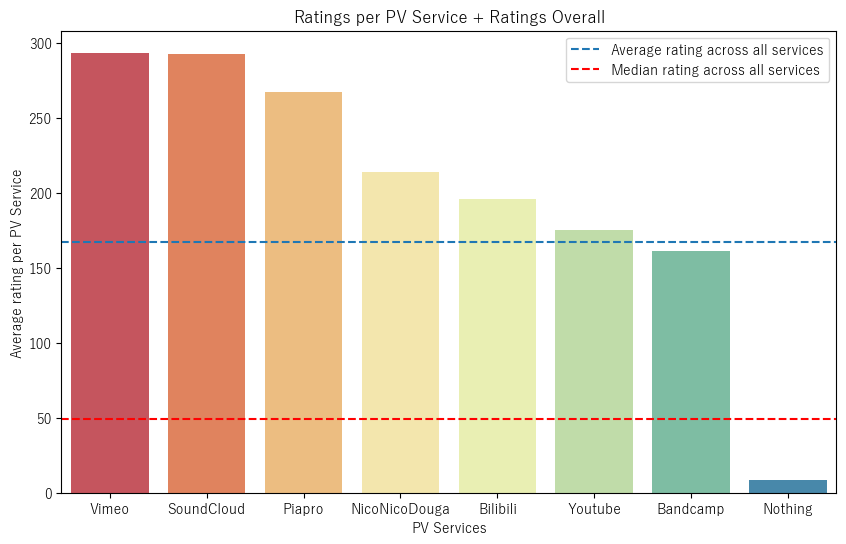

In [284]:
# Reset the index - this is so we can actually plot the data
songs_service_mean = songs_service_mean.reset_index("pv_services")

# Sort the values by rating so the data looks more cohesive
songs_service_mean = songs_service_mean.sort_values(by="rating", ascending=False)

# Create the figure
plt.figure(figsize=(10,6))

plot = sns.barplot(data=songs_service_mean, x="pv_services", y="rating", hue="pv_services", palette="Spectral")
plot.axhline(songs_rating_mean, linestyle="--", label="Average rating across all services") # Show true average rating
plot.axhline(songs_rating_median, linestyle="--", label="Median rating across all services", color="red") # Show true median rating
#plot.axhline(songs_rating_std, linestyle="--", label="Standard deviation of rating across all services", color="lightgreen") # Show true standard deviation -- visually this wasn't useful so I commented it out
plot.legend() # Create legend to make dotted lines clear

plt.title("Ratings per PV Service + Ratings Overall")
plt.xlabel("PV Services")
plt.ylabel("Average rating per PV Service")

plt.show()

I mentioned it earlier but seeing YouTube almost have the average overall rating is pretty crazy! It is barely over the average rating across all services, even after exploding the data which I would've expected to cause their average to be much higher.

I talk about it during Phase 1, but Bilibili is a Chinese social media app and there are Chinese producers who make VOCALOID songs. However, I never really mentioned Piapro all that much. Piapro is CFM's official website that allows users to post their original art or music of VOCALOID characters. It's more commonly used when producers want to release their instrumental/song in lossless audio quality, or when an artist who made visuals for a music video wants to repost the visuals in full image quality for fans to enjoy.

"Nothing" is expected - there are very few songs that don't have PV services with high ratings. It would be strange to have a popular song not be accessible at all. I'm sure it's happened before but it's a rare case and it makes sense the average looks the way it does for that column.

What *isn't* expected is Vimeo and SoundCloud having such a high average rating. I don't want to be mean, but who uses Vimeo as their main video-watching service? Same with SoundCloud. SoundCloud is popular with independent producers but it's not as common as it used to be and it is also not commonly used among VOCALOID fans or producers.

##### Distribution of Songs per PV Service

The averages for Vimeo and SoundCloud don't really add up... This visualization was probably (most likely) painfully obvious to do at the start. But I wanted to highlight why the averages turned out the way they did before I spoiled the reasoning why from the very beginning

Here's another chart (that I probably should've done since the start)! Here I'm comparing each PV service with how many songs are hosted on each service. The results are pretty wild.

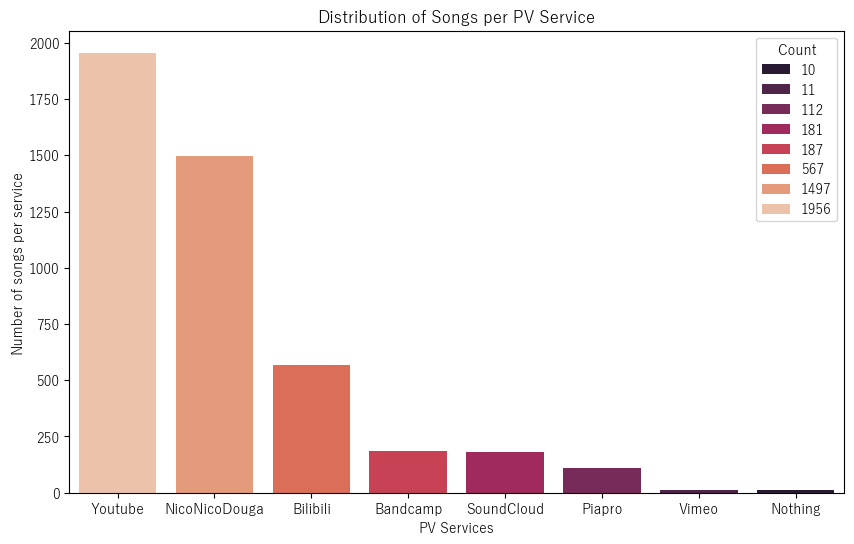

In [285]:
# Retrieve the count for every PV service
songs_service_count = songs_groupby_service['pv_services'].count()

# Sort the number of songs for each service
songs_service_count = songs_service_count.sort_values(ascending=False)

# Reset the index for the count and give it the name "Count" so we can refer to the column that holds our values
songs_service_count = songs_service_count.reset_index(name="Count")

# Create the figure
plt.figure(figsize=(10,6))

# Setting colors, creating the bar plot
p = sns.color_palette("rocket", n_colors=8)
sns.barplot(data=songs_service_count, x="pv_services", y="Count", hue="Count", palette=p)

plt.title("Distribution of Songs per PV Service")
plt.xlabel("PV Services")
plt.ylabel("Number of songs per service")

plt.show()

YouTube kind of wins by a landslide in terms of number of songs... since that's a LOT of songs. I can't imagine listening to that many songs in a year I don't think, though maybe my Spotify Wrapped can confirm that for me.

It has even more songs than NND and that was the main hub for VOCALOID content in the early days.

Given that the average ratings for Vimeo, Piapro, and SoundCloud were all very high in the previous chart, we can assume that those platforms are frequently/mainly used to redistribute popular songs to multiple websites.

You might notice that even though YouTube has way more songs added to their website, it has a noticeably lower average rating compared to NND that has less videos. This could be due to a couple of things:
1. The most popular fan favorite songs are older songs originally from NND
2. Fans have a heavy bias towards the Japanese language + nostalgia
3. Having more and being popular isn't always a good thing apparently
   - YouTube may have more videos, but a lot of those videos could have lower ratings that ultimately drag down YouTube's average song rating

This establishes that if you want to know where to go to access the *most* amount of content, YouTube will be your best bet. And even though NND is entirely in Japanese, given the amount of songs they have, cultural relevancy, and how high their average rating is, it's still worth considering clicking around!

#### A Different Way to Look at Popularity (Rating vs. Frequency)

I've tried a lot of different ways to plot out the data, but one of the most interesting is plotting out all of the songs and comparing between song ratings and setlist frequency.

This is related to the heat map we created earlier near the beginning of this section. The heat map showed us something fundamentally important about the data and it's that there is a real correlation between the rating of a song and how often it shows up in concert setlists. Rather than sticking to using just the heat map to prove this, why don't we visualize it in other ways and see specific song titles as well?

By plotting out all of our song data using a scatter plot, we can visualize all of the different songs much easier and see how dispersed the songs are. My implementation for this scatterplot is a little complicated, so I'll leave lots of comments to explain every step.

I also had to do something incredibly funny and weird to get the Japanese titles to display. Given that not everyone uses Windows I had to make sure it would load properly regardless of what OS you're running. If the fonts still don't render correctly for whatever reason please consult the PDF for the output!

Average setlist frequency: 19.516129032258064


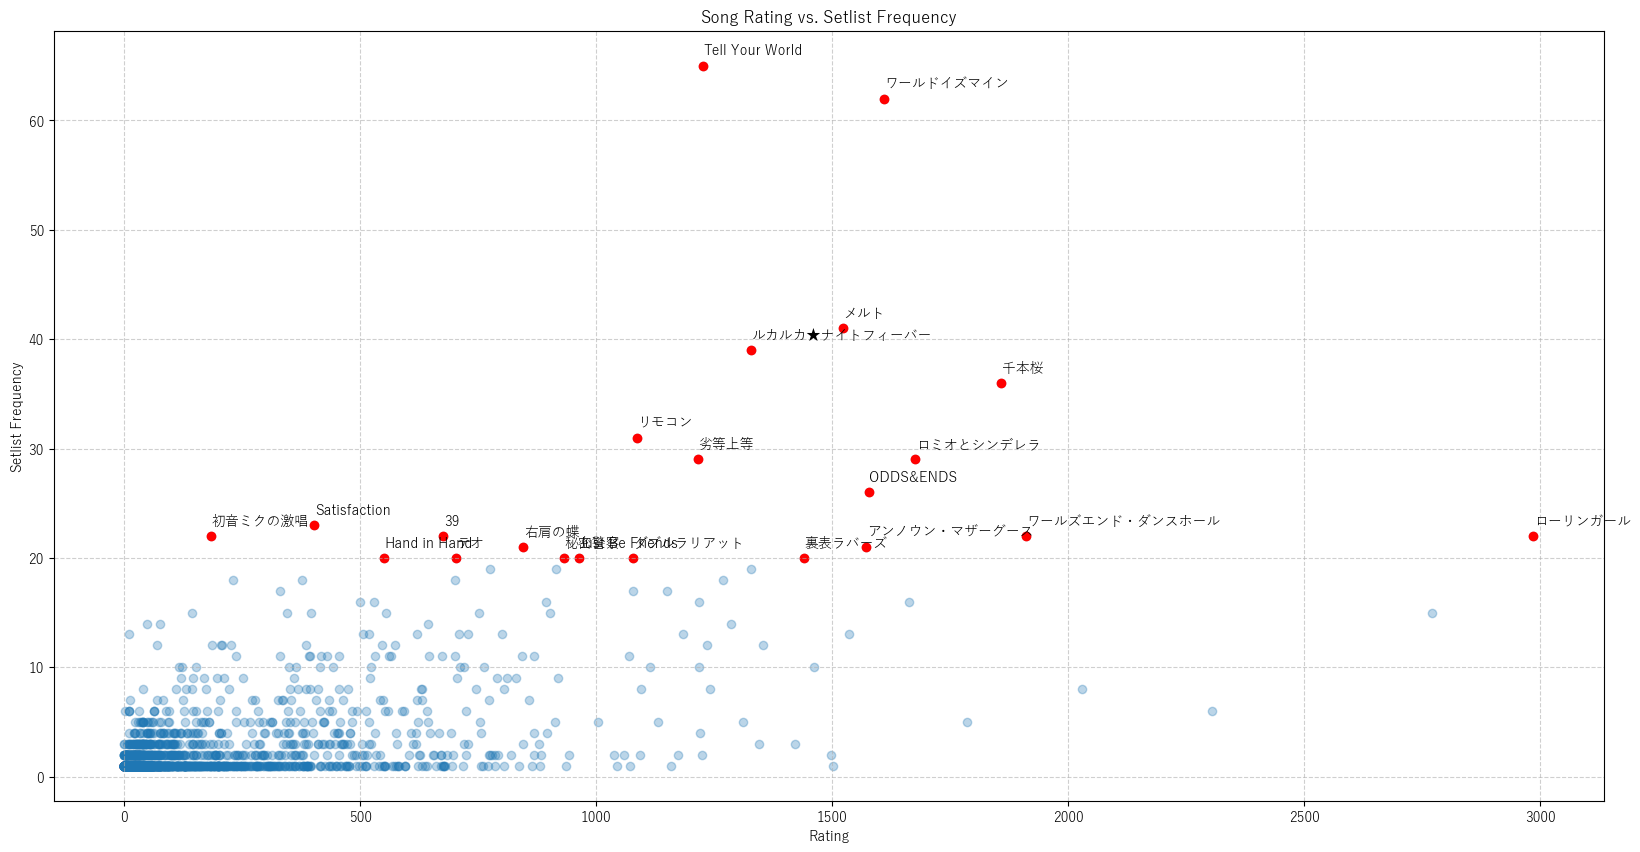

In [286]:
# Dictionary for specific fonts based on operating system
os_specific_font = {"Windows": "Yu Gothic", "Darwin": "Hiragino Sans", "Linux": "Noto Sans CJK JP"}

# Apply the specific font based on viewer's OS so they can view the Japanese-only titles
import platform
os = platform.system()
plt.rcParams["font.family"] = os_specific_font[os]

# Removing all duplicates in the setlist so we can determine the average setlist frequency correctly
drop_setlist_dupes = all_clean_songs_df.drop_duplicates(subset=["setlist_frequency"])
avg_setlist_freq = drop_setlist_dupes["setlist_frequency"].mean()
print(f"Average setlist frequency: {avg_setlist_freq}")

# Create the figure
plt.figure(figsize=(20,10))

# Use a scatter plot, comparing rating with setlist_frequency
plot = sns.scatterplot()
plot.scatter(all_clean_songs_df["rating"], all_clean_songs_df["setlist_frequency"], alpha=0.3)

# Create an extra collection of plots colored differently to represent the songs that play more than the average setlist frequency
highlight = all_clean_songs_df[all_clean_songs_df["setlist_frequency"] > avg_setlist_freq]
plot.scatter(highlight["rating"], highlight["setlist_frequency"], color="red")

# For labeling songs thay play more than the average frequency
for _,row in highlight.iterrows():
    ### Uncomment this for English titles
    #title = row["english_title"]
    #if(row["english_title"] == "None"):
    #    title = row["title"]
    plot.text(row["rating"] + 1, row["setlist_frequency"] + 1, row["title"]) 

plt.title("Song Rating vs. Setlist Frequency")
plt.xlabel("Rating")
plt.ylabel("Setlist Frequency")
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

Most of the songs are gathered around the bottom left corner, having both low ratings and low setlist frequency.

But as we look more towards either direction up or right, the higher the rating/setlist frequency is the more dispersed the data points get. There are a lot less songs as we start looking further out and the data is a lot less concentrated.

What's interesting is that the songs that play more than the average frequency vary greatly in terms of rating. Most are within the range that we'd expect (~1000 and above) but there are some entries that are unexpected:
- Some songs have extremely low ratings despite being played above average amount of times ("初音ミクの激唱" and "Satisfaction")
- "ローリンガール" has the highest rating of all songs but is not played as much as "Tell Your World" even though "Tell Your World" has only half the amount of ratings
   - This one is more expected given the context that wowaka (the producer) passed away rather tragically in 2019, and if any of his songs are played they are a lot more emotionally impactful for fans who've been familiar with his work for as long time
   - Since his passing, it seems like his music is now saved for more pivotal events such as the return of MIKU EXPO in 2024 or Hatsune Miku's first performance at Coachella where "Unknown Mother Goose" was one of the opening songs
   - This may also explain the incredibly high rating as well for this song - even if it isn't played often, fans cherish this particular song heavily
- "Tell Your World" is played more often than "ワールドイズマイン", which is surprising given that it's an incredibly iconic song for Hatsune Miku and the fandom considers it the #1 song everyone should know

Even if a song having a higher rating corresponds with having a higher setlist frequency, correlation does not mean causation. They're two different things, and we can see here that even if there is a pattern, the pattern doesn't necessarily guarantee that a song being popular will play more and vice versa.

Below is the list of all songs that played more often than the average setlist frequency. I'm used to reading the Japanese names, but the English names are also available below! 

In [287]:
top_place_ratings = all_clean_songs_df[all_clean_songs_df["setlist_frequency"] > avg_setlist_freq]

top_place_ratings.sort_values(by="rating", ascending=False)

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
123,ローリンガール,Rollin' Girl,wowaka feat. 初音ミク,196,22,12.318182,Original,"NicoNicoDouga, Youtube, SoundCloud",648,2985
74,ワールズエンド・ダンスホール,World's End Dancehall,"wowaka feat. 初音ミク, 巡音ルカ",218,22,11.227273,Original,"NicoNicoDouga, Youtube",403,1911
64,千本桜,A Thousand Cherry Blossoms,黒うさP feat. 初音ミク,246,36,12.361111,Original,"NicoNicoDouga, Youtube",388,1858
80,ロミオとシンデレラ,Romeo and Cinderella,doriko feat. 初音ミク,280,29,14.137931,Original,"NicoNicoDouga, Youtube, Bilibili",331,1676
152,ワールドイズマイン,World is Mine,"ryo, supercell feat. 初音ミク",255,62,13.500000,Original,"NicoNicoDouga, Youtube",303,1609
368,ODDS&ENDS,None,ryo feat. 初音ミク Append (Unknown),354,26,21.346154,Original,"NicoNicoDouga, Youtube, SoundCloud",340,1577
159,アンノウン・マザーグース,Unknown Mother-Goose,"wowaka, ヒトリエ feat. 初音ミク V4X (Dark)",285,21,13.238095,Original,"NicoNicoDouga, Youtube",357,1572
83,メルト,Melt,ryo feat. 初音ミク,256,41,24.292683,Original,"NicoNicoDouga, Youtube, SoundCloud",297,1522
77,裏表ラバーズ,Two-Sided Lovers,wowaka feat. 初音ミク,189,20,9.600000,Original,"NicoNicoDouga, Youtube, Piapro, Bilibili",307,1441
73,ルカルカ★ナイトフィーバー,Luka Luka★Night Fever,samfree feat. 巡音ルカ,239,39,16.307692,Original,"NicoNicoDouga, Youtube",261,1329


<p style="text-align: center; font-size: 50px;" >Thank you!</p>

<center><img src="https://media1.tenor.com/m/42n4xKaby6QAAAAC/retemyst.gif" alt="GIF of Hatsune Miku who turns around and looks more shocked with each phrase. 'I love music', she turns around a little. 'Especially Japanese' she begins to seem more surprised. 'I've recently got into this thing called VOCALOID', her eyes widen in pure shock!"></center>

# Phase 3: Question Answering and Conclusion

## Overview
We did quite a bit of EDA in the previous phase - looking at song length, popular songs, PV services... lots of investigating happening!

However, I will admit... I've been fooling around quite a bit. All of this data cleansing, analyzing the data, it was all just one big prepatory step for this phase.

You might remember long ago in Phase 1, I asked a couple of questions:
1. What songs will likely show up at the next VOCALOID concert in April (MIKU EXPO 2026)?
2. When will those songs play in the setlist? What is their average position?

The whole point of this project was to answer these questions + more! And we'll finally get to do that now. I'm expected to come up with 3 questions, but I may do a little bit extra. It may seem excessive, but it'll be necessary in order to fully understand everything.

__**My questions are**__:
1. How many songs has each VOCALOID performed thus far? What percentage do they each make up of all the setlists?
2. Who is the most popular VOCALOID?
3. What are the most popular songs for each VOCALOID?
4. What is the most likely setlist for the upcoming concert?

## Q1: How many songs has each VOCALOID performed thus far? What % do they each make up of all setlists?

"Each?" Yes, each. Hatsune Miku is "best girl", but she has friends who perform with her on stage! Although a lot of the official events have her name in it (i.e. MIKU EXPO), there are other performers who sing with her and also have their own individual songs that gave them their claim to fame.

I'm going to primarily be focusing on the main 6:

1. MEIKO
2. KAITO
3. Hatsune Miku (初音ミク)
4. Kagamine Rin (鏡音リン)
5. Kagamine Len (鏡音レン)
6. Megurine Luka (巡音ルカ)

<center><img src="magi_mira_2024.jpg" alt="Image of all the VOCALOID performers on stage at Magical Mirai 2024"></center>

### Creating a List For Each Idol

You may notice that I've also created a "various songs list" where the artist is listed as "various". That's because of the way VocaDB enters in artist information.

I haven't been able to absolutely 100% confirm what qualifies as "various" and what doesn't, but from what I can tell it seems like if there are X number of performers in one song (3 or more), the featured idols are listed as "various" rather than listing out every name. Unfortunately, there's no way to be able to pull the actual names of who performed in those songs, so I'll put all the "various" artist songs into their own lists.

In [ ]:
# Create a dataframe of all songs that each idol is in + "various" features
meiko_songs_list = all_clean_songs_df[all_clean_songs_df['artist'].str.contains('MEIKO')]
kaito_songs_list = all_clean_songs_df[all_clean_songs_df['artist'].str.contains('KAITO')]
miku_songs_list = all_clean_songs_df[all_clean_songs_df['artist'].str.contains('初音ミク')]
rin_songs_list = all_clean_songs_df[all_clean_songs_df['artist'].str.contains('鏡音リン')]
len_songs_list = all_clean_songs_df[all_clean_songs_df['artist'].str.contains('鏡音レン')]
luka_songs_list = all_clean_songs_df[all_clean_songs_df['artist'].str.contains('巡音ルカ')]
various_songs_list = all_clean_songs_df[all_clean_songs_df['artist'].str.contains('various')]

Out of curiosity, I wanted to see the total sum of songs from the main vocaloids + various artists in comparison to the entire dataframe.

Earlier in the notebook, I briefly mentioned there being other concerts, other companies, and therefore, other vocal synths out there that are not under CFM that wouldn't perform at MIKU EXPO.

In [323]:
# Summing up total songs between the main 6 idols and comparing against the entire dataframe
main_idol_sum = meiko_songs_list.shape[0] + kaito_songs_list.shape[0] + miku_songs_list.shape[0] + rin_songs_list.shape[0] + len_songs_list.shape[0] + luka_songs_list.shape[0] + various_songs_list.shape[0]
main_df_sum = all_clean_songs_df.shape[0]

print(f"Sum of songs performed by the main idols + various artists: {main_idol_sum}")
print(f"Sum of songs in the entire dataframe: {main_df_sum}")

Sum of songs performed by the main idols + various artists: 1216
Sum of songs in the entire dataframe: 2060


While a majority of the songs in this dataset are performed by the main CFM idols, 800 is still a significant number of songs that aren't performed by the main 6. It goes to show that not only is VOCALOID a greater community of people generally interested in vocal synths, it's also a product that companies are becoming vastly more interested in.

Some of the 800 songs use other vocal synths developed by CFM that aren't as popular anymore, but we're beginning to see the rise of other companies like AH-Software (AHS) and Dreamtonics who have their own vocal synths that are highly competitive. Some of them have even begun to perform at their own live shows. Kasane Teto (重音テト) - who I will mention again later on - especially has been making strides in becoming mainstream, so it's not just CFM that cares about vocal synth technology. There's been a greater interest and push towards advancing this technology all around, especially given the current interest in AI.

### Visualizing Setlist Percentages

We've created a new dataframe for each idol listing out all the songs they've performed in. By using these new dataframes, we can take a better look at the distribution of songs across all setlists per idol (in other words, how much stage time each of them get).

My instructor... he is not the biggest fan of pie charts. Not because they're bad or anything! They're just easily misused. So hopefully I'm using it right. If not, I'm really sorry!!

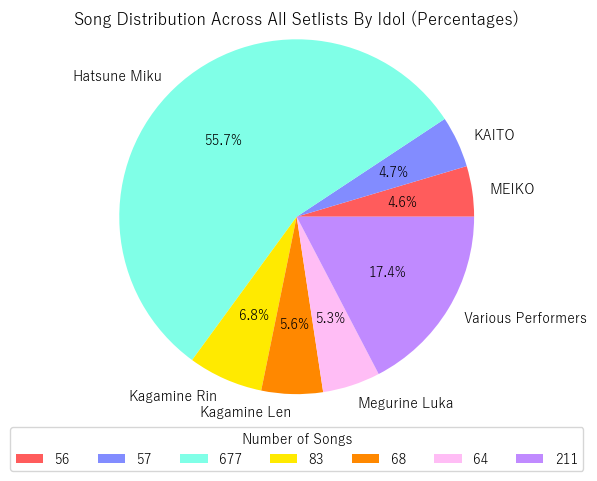

In [324]:
# Creating lists of names, amount of songs per idol, and using custom color palette to correlate with their character colors
labels = 'MEIKO', 'KAITO', 'Hatsune Miku', 'Kagamine Rin', 'Kagamine Len', 'Megurine Luka', 'Various Performers'
percentages = [meiko_songs_list.shape[0], kaito_songs_list.shape[0], miku_songs_list.shape[0], rin_songs_list.shape[0], len_songs_list.shape[0], luka_songs_list.shape[0], various_songs_list.shape[0]]
custom_palette = ['#FF5C5C', '#828CFF', '#80FFE7', '#FFEA00', "#FF8800", '#FFBDF5', '#C08AFF']

# Create a pie chart since we're trying to represent how much stage time each idol gets across the board
plt.pie(percentages, labels=labels, autopct='%1.1f%%', radius=1.2, colors=custom_palette)
plt.title("Song Distribution Across All Setlists By Idol (Percentages)")
plt.legend(percentages, bbox_to_anchor=(0.5, -0.05), loc='upper center', ncol=7, title="Number of Songs")

new_labels = plt.get_figlabels()

After looking at the results, is any of this surprising? Answer: Not really. Hatsune Miku popularized VOCALOID and she's a big reason as to why the community and products exist the way they do nowadays. Naturally, because of this, she would have way more songs and make up more of the setlist compared to the others. We've gotten to the point in general fandom circles where people recognize Miku, but we're far from people recognizing the other VOCALOIDs!

What I'm more surprised by is her not making up a larger percentage of the pie, as I personally expected her to be more in the ~60% range.

"Various Performers" being high is also surprising, but not really when considering:
1. All 6 idols often group together for one big hurrah
2. Some songs feature these idols in a trio, and that's enough for VocaDB to flag them as "various"

## Q2: Who is the most popular VOCALOID?

... It should be obvious, right? I mean... we just talked about the song distribution... that should mean something... right...?

Yes, it seems obvious, but it's still worth exploring! It's not good to say something without having the evidence to prove it.

Let's go ahead and take a look at the average song ratings per VOCALOID.

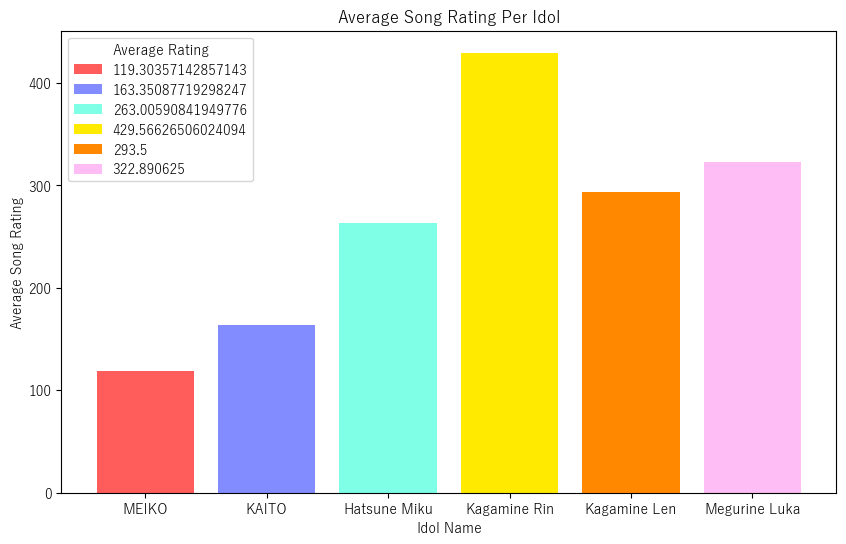

In [325]:
# Create a list of their names and the average song rating for each idol
names = ['MEIKO', 'KAITO', 'Hatsune Miku', 'Kagamine Rin', 'Kagamine Len', 'Megurine Luka']
avg_popularities = [meiko_songs_list['rating'].mean(), kaito_songs_list['rating'].mean(), miku_songs_list['rating'].mean(), rin_songs_list['rating'].mean(), len_songs_list['rating'].mean(), luka_songs_list['rating'].mean()]

# Putting that custom palette to good use again since I like color coding
plt.figure(figsize=(10,6))
p = custom_palette

# Create a bar plot
barplot = plt.bar(names, avg_popularities, color=custom_palette)
plt.title('Average Song Rating Per Idol')
plt.xlabel('Idol Name')
plt.ylabel('Average Song Rating')

# Legend provided so specific rating averages can be listed
plt.legend(barplot, avg_popularities, loc="upper left", title="Average Rating")

Okay. Hmm.

So another thing I didn't mention is that Miku has a lot of low rating songs. There are quite a bit of songs in her dataframe where the rating is just 0, and this happens with the other VOCALOIDs as well! It just happens quite notably with Miku because she is so popular.

I'm going to filter out any songs where the ratings are 0, and revisualize the chart.

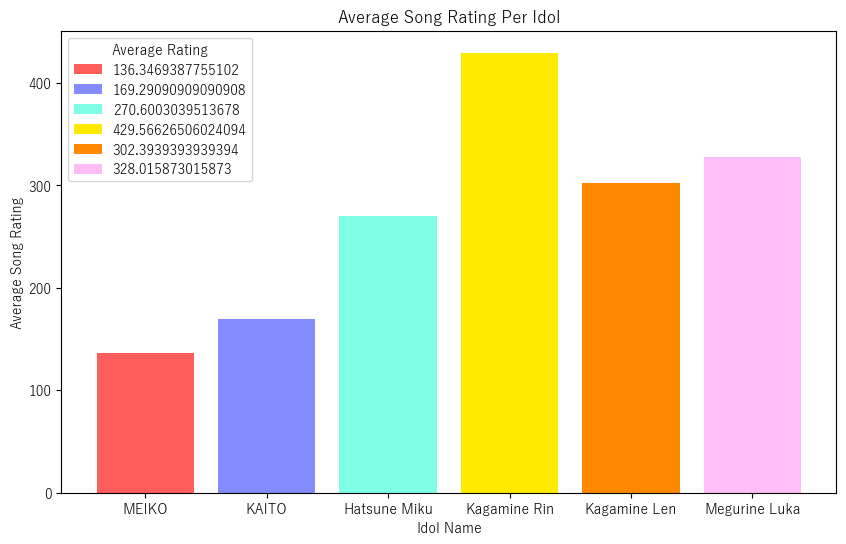

In [326]:
# Filter out all songs with rating == 0
popular_miku = miku_songs_list[miku_songs_list['rating'] > 0]
popular_meiko = meiko_songs_list[meiko_songs_list['rating'] > 0]
popular_kaito = kaito_songs_list[kaito_songs_list['rating'] > 0]
popular_rin = rin_songs_list[rin_songs_list['rating'] > 0]
popular_len = len_songs_list[len_songs_list['rating'] > 0]
popular_luka = luka_songs_list[luka_songs_list['rating'] > 0]

# Go through the same process again of creating the bar chart, this time the average ratings are filtered out to only include non-zeroes
names = ['MEIKO', 'KAITO', 'Hatsune Miku', 'Kagamine Rin', 'Kagamine Len', 'Megurine Luka']
avg_popularities = [popular_meiko['rating'].mean(), popular_kaito['rating'].mean(), popular_miku['rating'].mean(), popular_rin['rating'].mean(), popular_len['rating'].mean(), popular_luka['rating'].mean()]

# Create the chart once again
plt.figure(figsize=(10,6))
p = custom_palette

barplot = plt.bar(names, avg_popularities, color=custom_palette)
plt.title('Average Song Rating Per Idol')
plt.xlabel('Idol Name')
plt.ylabel('Average Song Rating')

plt.legend(barplot, avg_popularities, loc="upper left", title="Average Rating")

That didn't change anything!!! That might've just made it worse! 

So what's going on here?

This is a very similar issue we had when we looked at `pv_services` in Phase 2. Because Miku has more songs, her average popularity will naturally be lower because there will be more songs under her name that have lower ratings. We saw how Miku made up a whopping 55.7% of all setlists, it's entirely possible some of those songs just have lower ratings.

Even if Miku scores low when looking at overall average song ratings, it's undeniable she makes up the majority of all setlists. So even if we can't look at the average ratings to determine her popularity, we can look at the fact that she has the most amount of stage time. It gives the indication that the fans really love her and want to see more of her. And it makes sense when you know she's the figurehead of the community and fans look to her as the icon of vocal synth technology.

While it's undeniable that Hatsune Miku is the most popular of them all... it's also undeniable that there are definitely people who prefer the other VOCALOIDs as their 推し [oshi: a person's favorite member of an idol group] and there's nothing wrong with that! I won't show it here, but KAITO's voice provider 風雅なおと (Fuuga Naoto) is probably the BIGGEST KAITO fan I've ever seen in my life. Even if it may seem strange at first especially to those unfamiliar with Japanese idol culture, it's by far one of the sweetest things I've ever seen.

<center><img src="kaito_tweet.png" alt="A post from Naoto Fuuga's Twitter account, asking if his son - KAITO - has rizz"></center>

## Q3: What are the most popular songs for each VOCALOID?

We've established now that Hatsune Miku is by far the most popular VOCALOID. But just because she's the most popular doesn't mean the other VOCALOIDs don't have their own popular songs. I briefly talked about ways to measure popularity by looking at popular songs at the end of Phase 2. At the time, I made a scatterplot to highlight songs that played more than average and had higher ratings than average.

I'm going to do that again, but rather than do it across all setlist songs, this time we'll focus on each VOCALOID so we can get a good idea of the top songs for each idol.

### MEIKO's Most Popular Songs

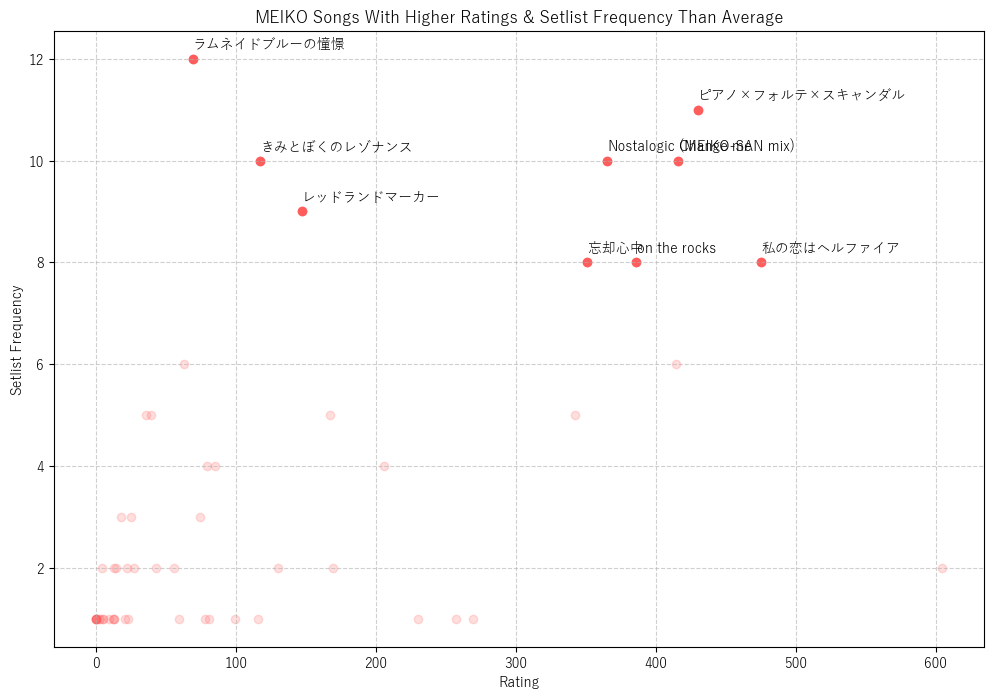

In [329]:
### FOR MEIKO'S DATA ###
### Code modified and taken from Phase 2 ###

# Apply specific font based on user's OS to render Japanese-only titles
os = platform.system()
plt.rcParams["font.family"] = os_specific_font[os]

# Remove all duplicates in setlist frequency to be able to determine the average accurately
drop_meiko_setlist_dupes = meiko_songs_list.drop_duplicates(subset=["setlist_frequency"])

# Plot all songs based on rating and setlist frequency
plt.figure(figsize=(12,8))

plot = sns.scatterplot()
plot.scatter(meiko_songs_list["rating"], meiko_songs_list["setlist_frequency"], alpha=0.2, color=custom_palette[0])

# Highlight songs that have been performed more times than the average
meiko_highlight = meiko_songs_list[meiko_songs_list["setlist_frequency"] > drop_meiko_setlist_dupes["setlist_frequency"].mean()]
plot.scatter(meiko_highlight["rating"], meiko_highlight["setlist_frequency"], color=custom_palette[0])

# Label songs that play more than the average setlist frequency
for _,row in meiko_highlight.iterrows():
    plot.text(row["rating"] + 0.2, row["setlist_frequency"] + 0.2, row["title"])

plt.title("MEIKO Songs With Higher Ratings & Setlist Frequency Than Average")
plt.xlabel("Rating")
plt.ylabel("Setlist Frequency")
plt.grid(True, linestyle="--", alpha=0.6)

Here are all of MEIKO's songs that have higher than average `setlist_frequency` and `rating`. The songs are pretty great too!

What's cool to see is that we went through a lot of effort earlier in the project to keep all the different versions of "Nostalogic" and it ultimately paid off. There were lots of different versions of that one song, and even if the version we went through the effort of keeping didn't make the final cut, this is actual proof that we *had* to care about that song to make sure it doesn't get excluded from our dataframe.

"It feels good when I'm right about something/I'm still hip with the kids/relevant" is what I'm trying to get at here.

MEIKO doesn't have many songs that are exceptionally popular, and you'll see this across all of the other VOCALOIDS (with the exception of Miku of course).

Given that she has the lowest average rating and has the least amount of stage time (making up only 4.6% of all setlists), it makes sense that she wouldn't have the opportunity to have many popular songs.

In [330]:
# MEIKO's highlighted songs listed out to show song details
meiko_highlight

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
72,ピアノ×フォルテ×スキャンダル,Piano×Forte×Scandal,OSTER project feat. MEIKO,232,11,12.272727,Original,"NicoNicoDouga, Youtube, Piapro",82,430
108,レッドランドマーカー,Red Land Marker,Twinfield feat. MEIKO V3 (Dark),204,9,9.444444,Original,"NicoNicoDouga, Youtube, Bilibili, Bandcamp",21,147
109,Nostalogic (MEIKO-SAN mix),None,yuukiss feat. MEIKO,257,10,11.600000,Remaster,"NicoNicoDouga, Youtube",73,365
147,きみとぼくのレゾナンス,Resonance Between You and Me,"斜め上P feat. MEIKO V3 (Straight), MEIKO V3 (Power)",274,10,10.100000,Original,"NicoNicoDouga, Youtube, Bilibili",15,117
482,私の恋はヘルファイア,My Love is Hellfire,"SLAVE.V-V-R feat. MEIKO V3 (Power), MEIKO V3 (...",195,8,7.625000,Original,"NicoNicoDouga, Youtube, Bilibili",85,475
489,on the rocks,None,"OSTER project feat. MEIKO V3 (Straight), KAITO...",265,8,13.500000,Cover,"NicoNicoDouga, Youtube",70,386
504,ラムネイドブルーの憧憬,Ramnade blue longing,アオトケイ feat. MEIKO V3 (Power),271,12,10.666667,Original,"NicoNicoDouga, Youtube",11,69
599,忘却心中,Love Suicide in Oblivion,"OPA, 0-9 feat. MEIKO",255,8,10.250000,Original,"NicoNicoDouga, Youtube, Piapro",71,351
682,Change me,None,shu-t feat. MEIKO,291,10,10.400000,Original,"NicoNicoDouga, Youtube",70,416


### KAITO's Most Popular Songs

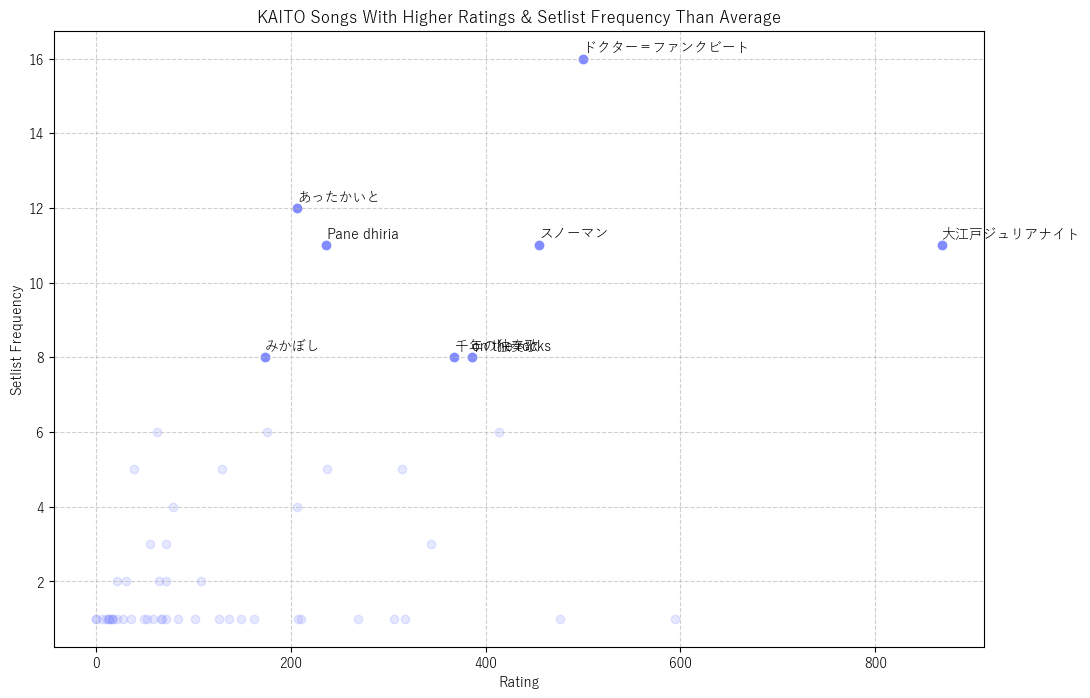

In [295]:
### FOR KAITO'S DATA ###
### Code modified and taken from Phase 2 ###

# Apply specific font based on user's OS to render Japanese-only titles
os = platform.system()
plt.rcParams["font.family"] = os_specific_font[os]

# Remove all duplicates in setlist frequency to be able to determine the average accurately
drop_kaito_setlist_dupes = kaito_songs_list.drop_duplicates(subset=["setlist_frequency"])

# Plot all songs based on rating and setlist frequency
plt.figure(figsize=(12,8))

plot = sns.scatterplot()
plot.scatter(kaito_songs_list["rating"], kaito_songs_list["setlist_frequency"], alpha=0.2, color=custom_palette[1])

# Highlight songs that have been performed more times than the average
kaito_highlight = kaito_songs_list[kaito_songs_list["setlist_frequency"] > drop_kaito_setlist_dupes["setlist_frequency"].mean()]
plot.scatter(kaito_highlight["rating"], kaito_highlight["setlist_frequency"], color=custom_palette[1])

# Label songs that play more than the average setlist frequency
for _,row in kaito_highlight.iterrows():
    plot.text(row["rating"] + 0.2, row["setlist_frequency"] + 0.2, row["title"])

plt.title("KAITO Songs With Higher Ratings & Setlist Frequency Than Average")
plt.xlabel("Rating")
plt.ylabel("Setlist Frequency")
plt.grid(True, linestyle="--", alpha=0.6)

Here are KAITO's most popular songs. They're a similar amount to how many songs MEIKO has, the only difference is that KAITO has 8 songs while she has 9. He doesn't make up much more than she does in terms of song distribution (4.7%), but it's interesting to see that he has less popular songs than MEIKO does.

What's especially surprising about his most popular songs is that "Cantarella" isn't in the highlights! I love this song and it seems to be popular amongst fans as well, given this year we're getting new merch featuring the character designs from that MV by Good Smile Company.

Perhaps it's left out to make way for other songs that are easier to sing/chant along with. I'd imagine chanting along to that song might be a bit difficult! 

<center><img src="GS_cantarella_preorder.png" alt="Image of Hatsune Miku and KAITO Nendoroids side by side in their Cantarella designs" width=475 height=375></center>

In [331]:
# Display all highlighted KAITO songs to make it easier to read
kaito_highlight

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
70,スノーマン,Snowman,halyosy feat. KAITO V3 (Straight),229,11,14.181818,Original,Youtube,77,455
107,大江戸ジュリアナイト,Ooedo Julia-Night,"Mitchie M feat. 初音ミク, KAITO V3 (Straight)",228,11,17.454545,Original,"NicoNicoDouga, Youtube, SoundCloud, Bilibili",170,868
488,ドクター＝ファンクビート,Doctor=Funk Beat,nyanyannya feat. KAITO,210,16,10.437500,Original,"NicoNicoDouga, Youtube, Bilibili",94,500
489,on the rocks,None,"OSTER project feat. MEIKO V3 (Straight), KAITO...",265,8,13.500000,Cover,"NicoNicoDouga, Youtube",70,386
511,あったかいと,Warm Kaito,halyosy feat. KAITO V3 (Straight),243,12,11.416667,Original,"NicoNicoDouga, Youtube",28,206
547,みかぼし,Star of Heaven,3106。 feat. KAITO,240,8,8.750000,Remix,"NicoNicoDouga, Youtube",25,173
640,Pane dhiria,None,新城P feat. KAITO,172,11,13.727273,Original,"NicoNicoDouga, Youtube, Piapro",38,236
642,千年の独奏歌,A Thousand-Year Solo,yanagiP feat. KAITO,277,8,12.125000,Original,"NicoNicoDouga, Youtube",66,368


### Hatsune Miku's Most Popular Songs

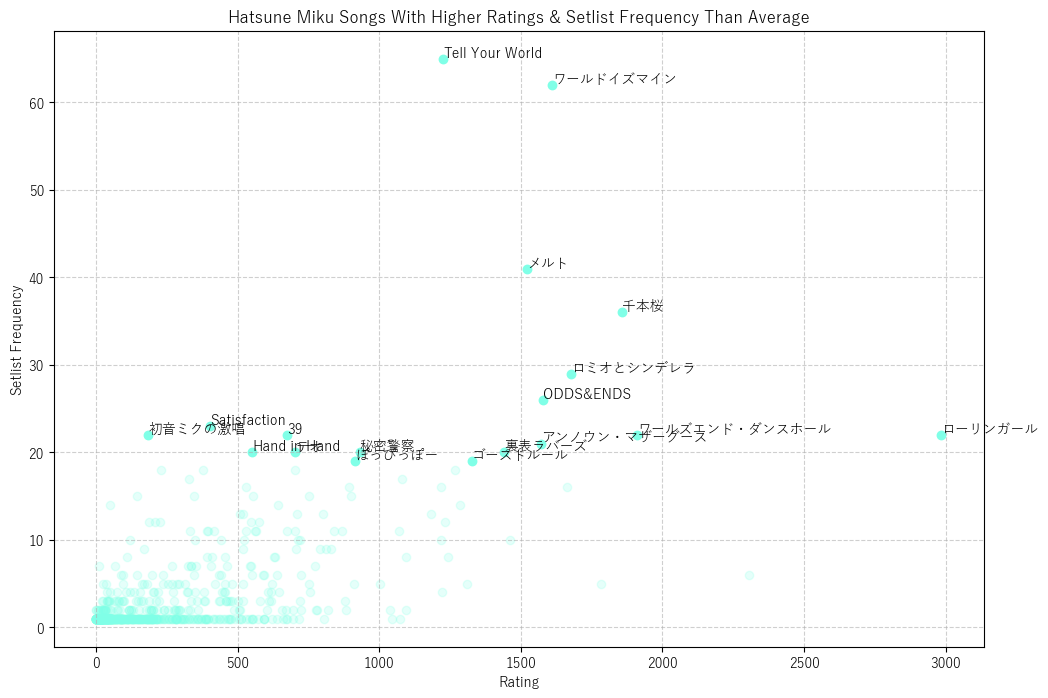

In [297]:
### FOR HATSUNE MIKU'S DATA ###
### Code modified and taken from Phase 2 ###

# Apply specific font based on user's OS to render Japanese-only titles
os = platform.system()
plt.rcParams["font.family"] = os_specific_font[os]

# Remove all duplicates in setlist frequency to be able to determine the average accurately
drop_miku_setlist_dupes = miku_songs_list.drop_duplicates(subset=["setlist_frequency"])

# Plot all songs based on rating and setlist frequency
plt.figure(figsize=(12,8))

plot = sns.scatterplot()
plot.scatter(miku_songs_list["rating"], miku_songs_list["setlist_frequency"], alpha=0.2, color=custom_palette[2])

# Highlight songs that have been performed more times than the average
miku_highlight = miku_songs_list[miku_songs_list["setlist_frequency"] > drop_miku_setlist_dupes["setlist_frequency"].mean()]
plot.scatter(miku_highlight["rating"], miku_highlight["setlist_frequency"], color=custom_palette[2])

# Label songs that play more than the average setlist frequency
for _,row in miku_highlight.iterrows():
    plot.text(row["rating"] + 0.2, row["setlist_frequency"] + 0.2, row["title"])

plt.title("Hatsune Miku Songs With Higher Ratings & Setlist Frequency Than Average")
plt.xlabel("Rating")
plt.ylabel("Setlist Frequency")
plt.grid(True, linestyle="--", alpha=0.6)

We talked quite a bit about Hatsune Miku's popularity and this chart shows just how many popular songs she has. She absolutely blows it out of the water in terms of song rating and setlist frequency.

Not too surprising, but Miku also has way more songs than the other VOCALOIDs. You can really see how she makes up 55.7% of all setlists given how many data points show through. Even if they aren't highlighted, we can see quite a concentration of songs in comparison to the other charts.

I'll display all the highlighted songs below as I have been. The first thing you'll notice is how many songs she has in comparison to the others (she has 18, which is nearly double what MEIKO and KAITO had)!

In [298]:
miku_highlight

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
59,テオ,Teo,"Kimura, Sakurai, Omoi feat. 初音ミク",209,20,9.450000,Original,"NicoNicoDouga, Youtube, Piapro, Bilibili",136,704
64,千本桜,A Thousand Cherry Blossoms,黒うさP feat. 初音ミク,246,36,12.361111,Original,"NicoNicoDouga, Youtube",388,1858
67,ぽっぴっぽー,Vegetable Juice,ラマーズP feat. 初音ミク,334,19,12.315789,Original,"NicoNicoDouga, Youtube",181,915
74,ワールズエンド・ダンスホール,World's End Dancehall,"wowaka feat. 初音ミク, 巡音ルカ",218,22,11.227273,Original,"NicoNicoDouga, Youtube",403,1911
77,裏表ラバーズ,Two-Sided Lovers,wowaka feat. 初音ミク,189,20,9.600000,Original,"NicoNicoDouga, Youtube, Piapro, Bilibili",307,1441
80,ロミオとシンデレラ,Romeo and Cinderella,doriko feat. 初音ミク,280,29,14.137931,Original,"NicoNicoDouga, Youtube, Bilibili",331,1676
83,メルト,Melt,ryo feat. 初音ミク,256,41,24.292683,Original,"NicoNicoDouga, Youtube, SoundCloud",297,1522
84,Hand in Hand,None,kz feat. 初音ミク,320,20,24.350000,Original,"NicoNicoDouga, Youtube, Bilibili",85,551
120,Satisfaction,None,kz feat. 初音ミク,201,23,18.000000,Original,Youtube,75,403
123,ローリンガール,Rollin' Girl,wowaka feat. 初音ミク,196,22,12.318182,Original,"NicoNicoDouga, Youtube, SoundCloud",648,2985


### Kagamine Rin's Most Popular Songs

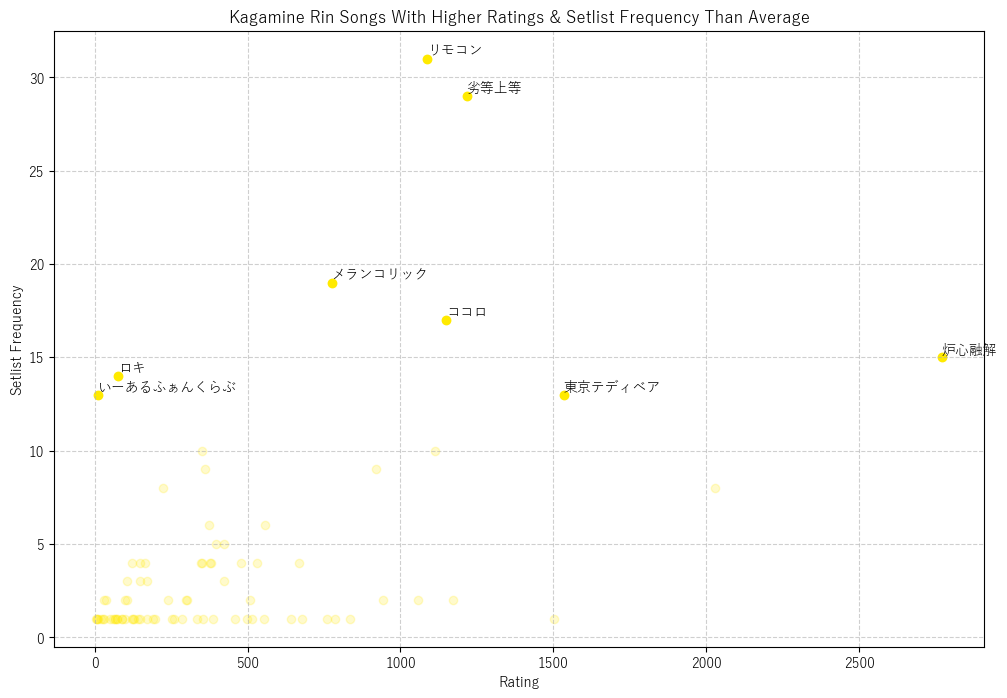

In [299]:
### FOR KAGAMINE RIN'S DATA ###
### Code modified and taken from Phase 2 ###

# Apply specific font based on user's OS to render Japanese-only titles
os = platform.system()
plt.rcParams["font.family"] = os_specific_font[os]

# Remove all duplicates in setlist frequency to be able to determine the average accurately
drop_rin_setlist_dupes = rin_songs_list.drop_duplicates(subset=["setlist_frequency"])

# Plot all songs based on rating and setlist frequency
plt.figure(figsize=(12,8))

plot = sns.scatterplot()
plot.scatter(rin_songs_list["rating"], rin_songs_list["setlist_frequency"], alpha=0.2, color=custom_palette[3])

# Highlight songs that have been performed more times than the average
rin_highlight = rin_songs_list[rin_songs_list["setlist_frequency"] > drop_rin_setlist_dupes["setlist_frequency"].mean()]
plot.scatter(rin_highlight["rating"], rin_highlight["setlist_frequency"], color=custom_palette[3])

# Label songs that play more than the average setlist frequency
for _,row in rin_highlight.iterrows():
    plot.text(row["rating"] + 0.2, row["setlist_frequency"] + 0.2, row["title"])

plt.title("Kagamine Rin Songs With Higher Ratings & Setlist Frequency Than Average")
plt.xlabel("Rating")
plt.ylabel("Setlist Frequency")
plt.grid(True, linestyle="--", alpha=0.6)

Here is the first Kagamine of the two! Rin also doesn't have many popular songs, however, what popular songs she *does* have under her belt have incredibly high ratings in comparison to the other VOCALOIDs. So even if she has few songs to highlight, what is highlighted stands out very much compared to the other vocalists.

In [300]:
rin_highlight

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
96,炉心融解,Meltdown,iroha(sasaki) feat. 鏡音リン,333,15,11.800000,Original,"NicoNicoDouga, Youtube, SoundCloud, Bilibili",610,2770
114,東京テディベア,Tokyo Teddy Bear,"Neru, おればななP feat. 鏡音リン, 鏡音リン Append (Sweet)",193,13,12.615385,Original,"NicoNicoDouga, Youtube",296,1535
149,リモコン,Remote Control,"じーざすP, WONDERFUL★OPPORTUNITY! feat. 鏡音リン, 鏡音レン",312,31,14.419355,Original,"NicoNicoDouga, Youtube",206,1086
189,劣等上等,BRING IT ON,"Giga feat. 鏡音リン, 鏡音レン",235,29,12.206897,Original,"NicoNicoDouga, Youtube, Bilibili",244,1216
193,メランコリック,Melancholic,Junky feat. 鏡音リン,219,19,10.736842,Original,"NicoNicoDouga, Youtube, Bilibili",126,775
559,いーあるふぁんくらぶ,"1, 2 Fanclub","みきとP feat. 鏡音リン, 鏡音レン",238,13,15.000000,Cover,Youtube,1,11
567,ロキ,ROKI,"みきとP feat. 鏡音リン V4X (Power), 鏡音レン V4X (Power)",232,14,10.928571,Cover,Youtube,15,77
598,ココロ,Heart,トラボルタ feat. 鏡音リン,290,17,12.470588,Original,"NicoNicoDouga, Youtube",234,1149


### Kagamine Len's Most Popular Songs

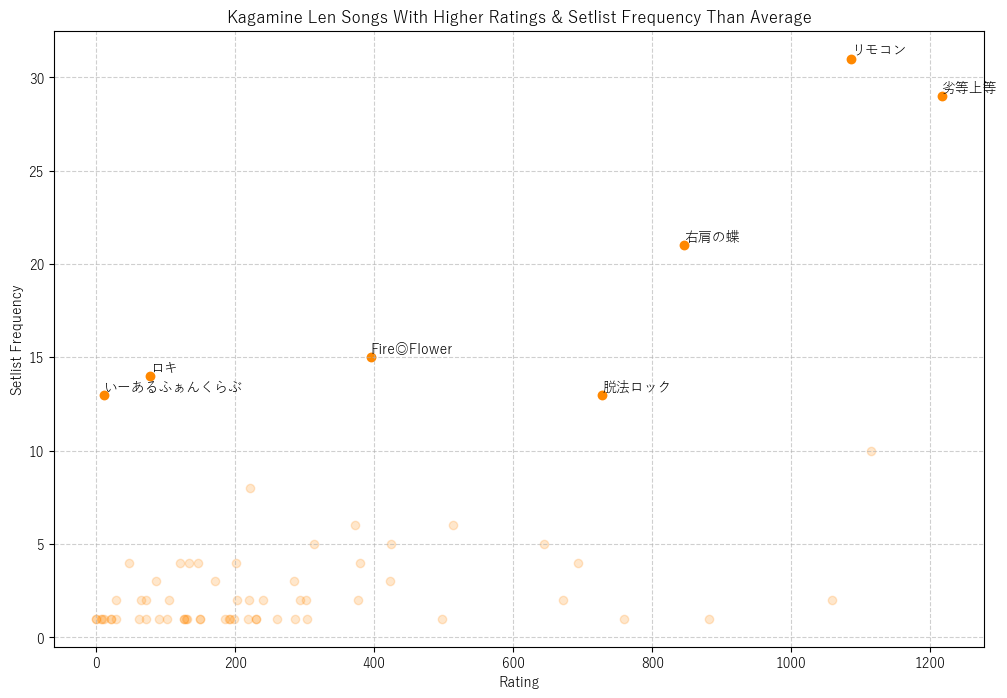

In [301]:
### FOR KAGAMINE LEN'S DATA ###
### Code modified and taken from Phase 2 ###

# Apply specific font based on user's OS to render Japanese-only titles
os = platform.system()
plt.rcParams["font.family"] = os_specific_font[os]

# Remove all duplicates in setlist frequency to be able to determine the average accurately
drop_len_setlist_dupes = len_songs_list.drop_duplicates(subset=["setlist_frequency"])

# Plot all songs based on rating and setlist frequency
plt.figure(figsize=(12,8))

plot = sns.scatterplot()
plot.scatter(len_songs_list["rating"], len_songs_list["setlist_frequency"], alpha=0.2, color=custom_palette[4])

# Highlight songs that have been performed more times than the average
len_highlight = len_songs_list[len_songs_list["setlist_frequency"] > drop_len_setlist_dupes["setlist_frequency"].mean()]
plot.scatter(len_highlight["rating"], len_highlight["setlist_frequency"], color=custom_palette[4])

# Label songs that play more than the average setlist frequency
for _,row in len_highlight.iterrows():
    plot.text(row["rating"] + 0.2, row["setlist_frequency"] + 0.2, row["title"])

plt.title("Kagamine Len Songs With Higher Ratings & Setlist Frequency Than Average")
plt.xlabel("Rating")
plt.ylabel("Setlist Frequency")
plt.grid(True, linestyle="--", alpha=0.6)

Here is the second Kagamine twin! As you can see, Len is also in the same boat as Rin. He has few songs, his twin having one extra highlighted song compared to him (he has 7, she has 8 songs). Also, even if they are twins, his ratings aren't nearly as high as his female counterpart.

While Len's top 2 songs are duets that he does with his twin, Rin's top 2 songs are actually solos that she performs by herself! So even if they are twins and are often seen together, one twin seems to be more popular and have more individual acts than the other.

In [302]:
len_highlight

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
149,リモコン,Remote Control,"じーざすP, WONDERFUL★OPPORTUNITY! feat. 鏡音リン, 鏡音レン",312,31,14.419355,Original,"NicoNicoDouga, Youtube",206,1086
189,劣等上等,BRING IT ON,"Giga feat. 鏡音リン, 鏡音レン",235,29,12.206897,Original,"NicoNicoDouga, Youtube, Bilibili",244,1216
415,脱法ロック,Law-evading Rock,Neru feat. 鏡音レン V4X (Power),188,13,10.230769,Original,"NicoNicoDouga, Youtube",132,728
559,いーあるふぁんくらぶ,"1, 2 Fanclub","みきとP feat. 鏡音リン, 鏡音レン",238,13,15.000000,Cover,Youtube,1,11
567,ロキ,ROKI,"みきとP feat. 鏡音リン V4X (Power), 鏡音レン V4X (Power)",232,14,10.928571,Cover,Youtube,15,77
600,右肩の蝶,Butterfly on Your Right Shoulder,のりぴー feat. 鏡音レン,265,21,12.904762,Remix,"NicoNicoDouga, Youtube, Piapro",174,846
621,Fire◎Flower,None,"halyosy, is feat. 鏡音レン",260,15,12.933333,Original,"NicoNicoDouga, Youtube, Piapro",57,395


### Megurine Luka's Most Popular Songs

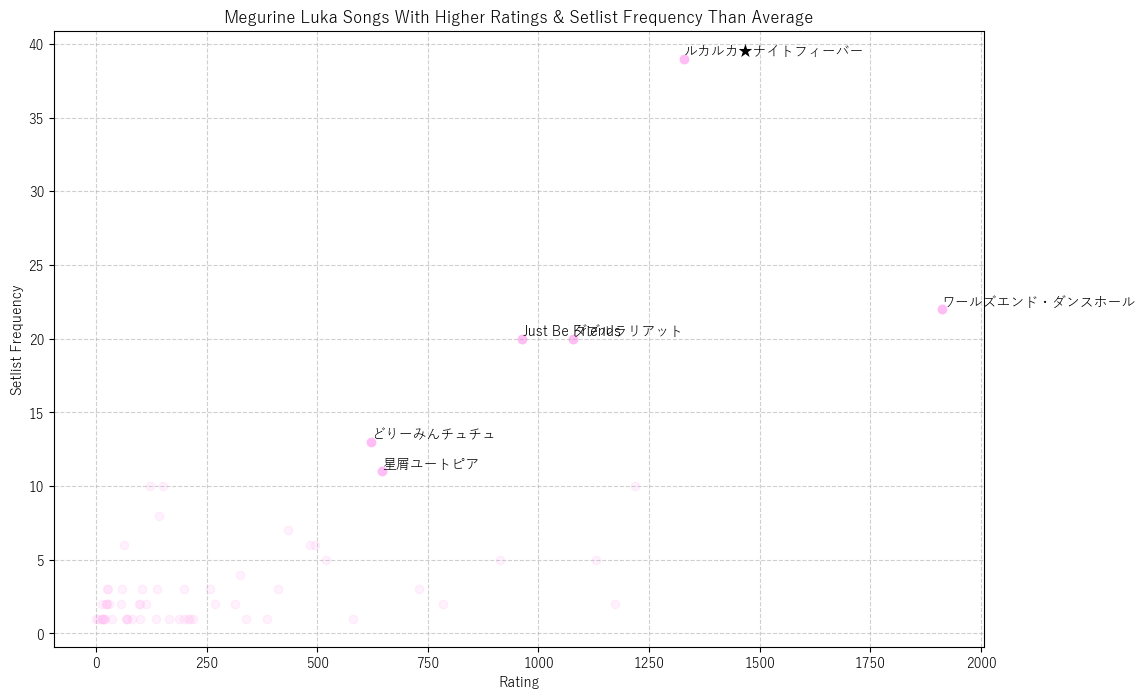

In [303]:
### FOR MEGURINE LUKA'S DATA ###
### Code modified and taken from Phase 2 ###

# Apply specific font based on user's OS to render Japanese-only titles
os = platform.system()
plt.rcParams["font.family"] = os_specific_font[os]

# Remove all duplicates in setlist frequency to be able to determine the average accurately
drop_luka_setlist_dupes = luka_songs_list.drop_duplicates(subset=["setlist_frequency"])

# Plot all songs based on rating and setlist frequency
plt.figure(figsize=(12,8))

plot = sns.scatterplot()
plot.scatter(luka_songs_list["rating"], luka_songs_list["setlist_frequency"], alpha=0.2, color=custom_palette[5])

# Highlight songs that have been performed more times than the average
luka_highlight = luka_songs_list[luka_songs_list["setlist_frequency"] > drop_luka_setlist_dupes["setlist_frequency"].mean()]
plot.scatter(luka_highlight["rating"], luka_highlight["setlist_frequency"], color=custom_palette[5])

# Label songs that play more than the average setlist frequency
for _,row in luka_highlight.iterrows():
    plot.text(row["rating"] + 0.2, row["setlist_frequency"] + 0.2, row["title"])

plt.title("Megurine Luka Songs With Higher Ratings & Setlist Frequency Than Average")
plt.xlabel("Rating")
plt.ylabel("Setlist Frequency")
plt.grid(True, linestyle="--", alpha=0.6)

Here are Luka's results. If we're not counting "various artists", Luka has the least amount of notable songs (6). :(

But out of all the other VOCALOIDs (excluding Miku), she has the highest `setlist_frequency` for all of her songs all around. They've all been played >10 times, and her top song "ルカルカ★ナイトフィーバー	Luka Luka★Night Fever" has been played many more times compared to the other VOCALOIDs who have only had their songs played a maximum of ~10 times. So while she has the least amount of popular songs, they seem to be played relatively consistently across events in comparison to the other VOCALOIDs.

In [304]:
luka_highlight

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
73,ルカルカ★ナイトフィーバー,Luka Luka★Night Fever,samfree feat. 巡音ルカ,239,39,16.307692,Original,"NicoNicoDouga, Youtube",261,1329
74,ワールズエンド・ダンスホール,World's End Dancehall,"wowaka feat. 初音ミク, 巡音ルカ",218,22,11.227273,Original,"NicoNicoDouga, Youtube",403,1911
342,どりーみんチュチュ,Dreamin Chuchu,emon(Tes.) feat. 巡音ルカ,241,13,12.923077,Original,"NicoNicoDouga, Youtube, Bilibili",103,621
412,ダブルラリアット,Double Lariat,アゴアニキ feat. 巡音ルカ,207,20,16.050000,Original,"NicoNicoDouga, Youtube, Piapro",229,1077
510,星屑ユートピア,Stardust Utopia,otetsu feat. 巡音ルカ,263,11,16.000000,Original,"NicoNicoDouga, Youtube, Piapro",128,646
656,Just Be Friends,None,Dixie Flatline feat. 巡音ルカ,304,20,16.450000,Original,"NicoNicoDouga, Youtube, Piapro",171,963


### Various Artists' Most Popular Songs

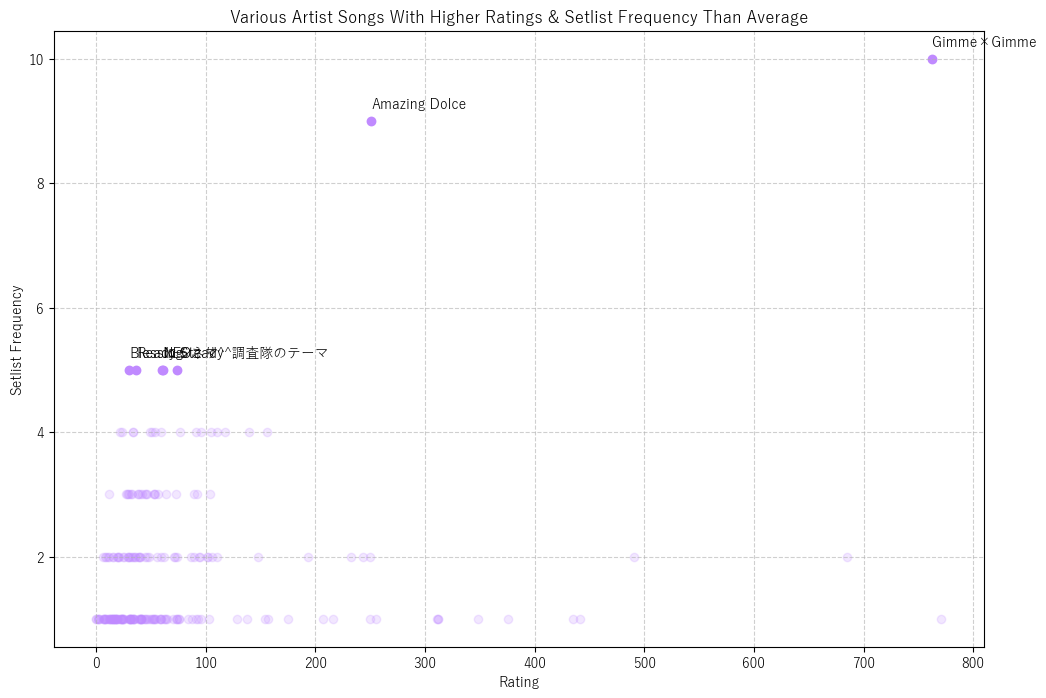

In [305]:
### FOR VARIOUS ARTISTS' DATA ###
### Code modified and taken from Phase 2 ###

# Apply specific font based on user's OS to render Japanese-only titles
os = platform.system()
plt.rcParams["font.family"] = os_specific_font[os]

# Remove all duplicates in setlist frequency to be able to determine the average accurately
drop_various_setlist_dupes = various_songs_list.drop_duplicates(subset=["setlist_frequency"])

# Plot all songs based on rating and setlist frequency
plt.figure(figsize=(12,8))

plot = sns.scatterplot()
plot.scatter(various_songs_list["rating"], various_songs_list["setlist_frequency"], alpha=0.2, color=custom_palette[6])

# Highlight songs that have been performed more times than the average
various_highlight = various_songs_list[various_songs_list["setlist_frequency"] > drop_various_setlist_dupes["setlist_frequency"].mean()]
plot.scatter(various_highlight["rating"], various_highlight["setlist_frequency"], color=custom_palette[6])

# Label songs that play more than the average setlist frequency
for _,row in various_highlight.iterrows():
    plot.text(row["rating"] + 0.2, row["setlist_frequency"] + 0.2, row["title"])

plt.title("Various Artist Songs With Higher Ratings & Setlist Frequency Than Average")
plt.xlabel("Rating")
plt.ylabel("Setlist Frequency")
plt.grid(True, linestyle="--", alpha=0.6)

The "feat. various" category is... an interesting one. When I rendered this chart at first, I didn't really know what to think. I mean... all of those data points being so perfectly horizontal... it seems strange, doesn't it? But no, they're all real songs. I made sure to check and they indeed are all real songs, the data just presents itself strangely.

It's not important right now and I'll talk more about it later, but there's a number of songs here that won't be included in our final result. Just focus on the top 4 songs since those are the ones we really care about.

A lot of these various titles present strangely on the chart and that's because they've all only been played a handful of times each. These type of songs seem to primarily be songs featuring 3+ vocalists or the entire group, which is rare! It's uncommon for a song to have that many vocalists, and also to gain popularity at the same time. Part of why the data seems so offputting initially is because these songs seem to be played very sparingly, due to the fact that they aren't as popular as individual/duet tracks.

I would guess that if any of these songs are going to be played, it would have to be a song that fans are already familiar with, or alternatively used to add some variety to the setlist.

Fun fact: I got to see "Gimme×Gimme" live at MIKU EXPO 2024 and it was awesome! It was so cool seeing them wear the Rockin' Stone and Burning Stone outfits.

In [306]:
various_highlight

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
75,Amazing Dolce,None,"ひとしずくP, やま△ feat. various",239,9,12.222222,Original,"NicoNicoDouga, Youtube",37,251
497,Blessing,None,halyosy feat. various,271,5,28.000000,Remaster,Youtube,6,30
680,Gimme×Gimme,None,"八王子P, Giga feat. various",220,10,11.100000,Original,"NicoNicoDouga, Youtube, Bilibili",138,762
1242,Ready Steady,None,Giga feat. various,210,5,10.000000,Remix,Youtube,9,37
1243,シネマ,Cinema,Ayase feat. various,211,5,13.200000,Cover,"NicoNicoDouga, Youtube",16,74
1267,にっこり^^調査隊のテーマ,Niccori^^ Survey Team Theme,"じーざすP, WONDERFUL★OPPORTUNITY! feat. various",207,5,14.200000,Cover,"NicoNicoDouga, Youtube, Bilibili",17,61
1295,NEO,None,じん feat. various,183,5,28.000000,Cover,"NicoNicoDouga, Youtube",10,60


### Visualizing All Idols' Most Popular Songs
Just for fun, I'll graph ALL of the most popular songs between all of the different VOCALOIDs. I'll be including the "various" group as well, and will color code all of them so it's easy to tell whose song is whose.

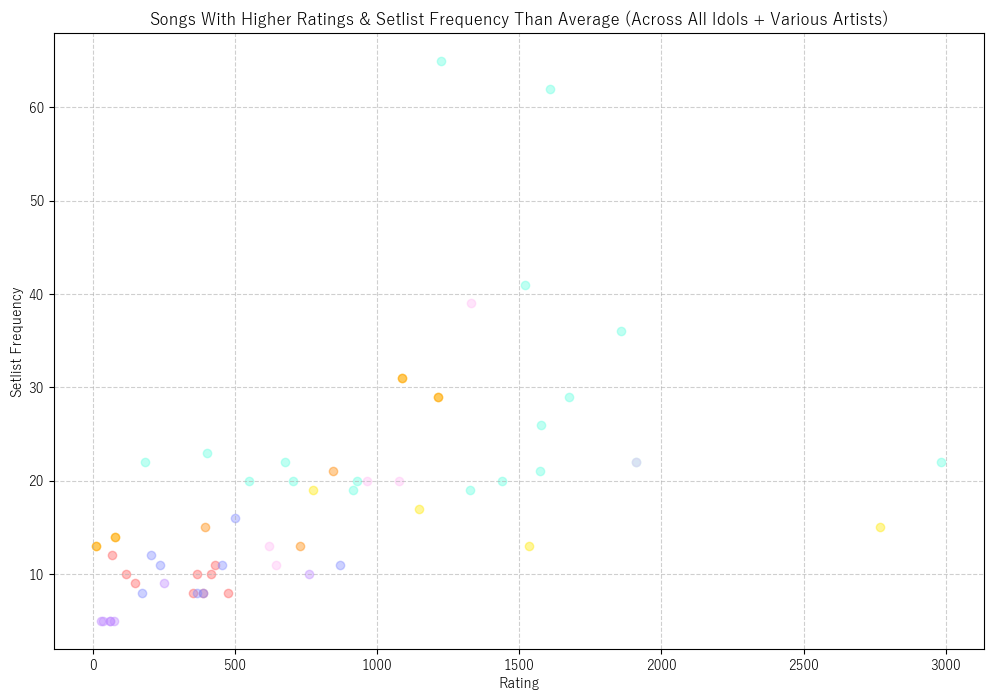

In [307]:
### FOR ALL VOCALOIDS' DATA ###
### Code modified and taken from Phase 2 ###

# Apply specific font based on user's OS to render Japanese-only titles
os = platform.system()
plt.rcParams["font.family"] = os_specific_font[os]

# Plot all songs based on rating and setlist frequency
plt.figure(figsize=(12,8))
plot = sns.scatterplot()

# Plot the highlights of each idol
plot.scatter(meiko_highlight["rating"], meiko_highlight["setlist_frequency"], alpha=0.4, color=custom_palette[0])
plot.scatter(kaito_highlight["rating"], kaito_highlight["setlist_frequency"], alpha=0.4, color=custom_palette[1])
plot.scatter(miku_highlight["rating"], miku_highlight["setlist_frequency"], alpha=0.5, color=custom_palette[2])
plot.scatter(rin_highlight["rating"], rin_highlight["setlist_frequency"], alpha=0.4, color=custom_palette[3])
plot.scatter(len_highlight["rating"], len_highlight["setlist_frequency"], alpha=0.4, color=custom_palette[4])
plot.scatter(luka_highlight["rating"], luka_highlight["setlist_frequency"], alpha=0.4, color=custom_palette[5])
plot.scatter(various_highlight["rating"], various_highlight["setlist_frequency"], alpha = 0.4, color=custom_palette[6])

plt.title("Songs With Higher Ratings & Setlist Frequency Than Average (Across All Idols + Various Artists)")
plt.xlabel("Rating")
plt.ylabel("Setlist Frequency")
plt.grid(True, linestyle="--", alpha=0.6)

Wanted to graph this for fun just to give a visual idea of how much Miku dominates the board

## Q4: What is the most likely setlist for the upcoming concert?

<center><img src="https://media1.tenor.com/m/bTUNbbXE7IcAAAAC/miku-hatsune-miku.gif" alt="GIF of Magical Cure Love Shot MV doing the Miku Miku Beam"></center>
<p style="text-align: center; font-size: 14px;" >⚠️ Flashing images for photosensitive viewers! ⚠️</p>


And now it's time for the moment you've been waiting for! Well... at least I have definitely been looking forward to it!

Let's start talking about and making predictions!

### Doing the Math

Before we can continue, we have to start out with doing some math to make sure we're making more accurate predictions about the setlist.

*potential jeering in the distance*

#### Average Setlist Length
So, kind of crazy, but, I never thought to calculate this until now...

Unfortunately, I was a fool when I was creating my script to pull all the data from VocaDB's API. I didn't think to include a table that holds all of the setlist lengths...

Fortunately, I am less of a fool in that I already know the lengths of the setlists on average for all the official concert events, and it usually lands anywhere between ~24-30 songs. (source: trust me)

Let's settle with 30 for this scenario, just so we have a nice and even number.

#### Song Distribution Per Idol

We talked about the song distribution per idol earlier, and the percentage of songs each idol makes up across all setlists. While this is related to the pie chart I created earlier, I won't be recreating it. Instead, I'll list out the percentages here explicitly so we can focus on the math.

**From the pie chart, the percentage of songs belong to each idol were (from highest to lowest)**:
- Hatsune Miku (55.7%)
- Various Performers (17.4%)
- Kagamine Rin (6.8%)
- Kagamine Len (5.6%)
- Megurine Luka (5.3%)
- KAITO (4.7%)
- MEIKO (4.6%)

**Assuming the setlist length is 30 songs, this is how many songs each performer would perform**:

Calculation: (setlist length) * (percentage, represented as a decimal)

- Hatsune Miku (16.71 songs)
- Various Performers (5.22 songs)
- Kagamine Rin (2.04 songs)
- Kagamine Len (1.68 songs)
- Megurine Luka (1.59 songs)
- KAITO (1.41 songs)
- MEIKO (1.38 songs)

**Now we round each number so we get whole number values (because I would hope we wouldn't be playing 1 1/2 of songs during the show)**:
- Hatsune Miku (16.71 songs) ==> 17 songs
- Various Performers (5.22 songs) ==> 5 songs
- Kagamine Rin (2.04 songs) ==> 2 songs
- Kagamine Len (1.68 songs) ==> 2 songs
- Megurine Luka (1.59 songs) ==> 2 songs
- KAITO (1.41 songs) ==> 1 song
- MEIKO (1.38 songs) ==> 1 song

This all adds up to 30 songs, distributed across all the idols + various group performances.

### Which Songs Each Idol Will Perform - Predictions + Justifications + Context

Now it's time to make predictions!

Before we do that, here's some context:

Something important to note about official VOCALOID concerts is that there are theme songs for each concert, along with song contests!

Each concert has their own theme and art direction that the company (CFM) wants to go towards for that year. This year's MIKU EXPO 2026 is themed around sweets. The artist who produces the theme song for the year is chosen by CFM, but there is also a song contest that CFM hosts for their upcoming concerts as well. This allows fans to submit their original creations and have a chance to have their song performed live on stage if it's popular within the company's voting committee.

This will be important for when we start making predictions, since the theme song and contest song immediately guarantees what will be played at the show even if the show hasn't happened yet.

Also, for each idol, I will primarily be doing my predictions based on the setlist frequency of their songs. However, wherever it seems necessary, I will also make arguments to change or include certain songs for each idol based on my own current knowledge of the fandom and past concerts that isn't fully reflected within the data.

#### Hatsune Miku

Based on our math, Miku should be performing 17 songs.

I gave some context earlier, but we already know 2 songs that will definitely be performed at the show:
1. "CONNECT:COMMUNE" by FLAVOR FOLEY (concert theme song)
2. "Room for a Fantasy" by nostraightanswer (contest song)

Now that leaves us with 15 songs that we still have to make predictions on.

Earlier, I made a dataframe that contains all of the top songs performed by Hatsune Miku. If we sort by `avg_setlist_order`, `setlist_frequency`, and `rating`, here are the first 15 results:

In [308]:
miku_setlist = miku_highlight.sort_values(by=['setlist_frequency', 'rating'], ascending=[False, False]).head(15)

miku_setlist

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
268,Tell Your World,None,kz feat. 初音ミク,257,65,18.169231,Remix,Youtube,218,1226
152,ワールドイズマイン,World is Mine,"ryo, supercell feat. 初音ミク",255,62,13.500000,Original,"NicoNicoDouga, Youtube",303,1609
83,メルト,Melt,ryo feat. 初音ミク,256,41,24.292683,Original,"NicoNicoDouga, Youtube, SoundCloud",297,1522
64,千本桜,A Thousand Cherry Blossoms,黒うさP feat. 初音ミク,246,36,12.361111,Original,"NicoNicoDouga, Youtube",388,1858
80,ロミオとシンデレラ,Romeo and Cinderella,doriko feat. 初音ミク,280,29,14.137931,Original,"NicoNicoDouga, Youtube, Bilibili",331,1676
368,ODDS&ENDS,None,ryo feat. 初音ミク Append (Unknown),354,26,21.346154,Original,"NicoNicoDouga, Youtube, SoundCloud",340,1577
120,Satisfaction,None,kz feat. 初音ミク,201,23,18.000000,Original,Youtube,75,403
123,ローリンガール,Rollin' Girl,wowaka feat. 初音ミク,196,22,12.318182,Original,"NicoNicoDouga, Youtube, SoundCloud",648,2985
74,ワールズエンド・ダンスホール,World's End Dancehall,"wowaka feat. 初音ミク, 巡音ルカ",218,22,11.227273,Original,"NicoNicoDouga, Youtube",403,1911
286,39,None,"sasakure.UK, DECO*27 feat. 初音ミク",220,22,22.227273,Original,"NicoNicoDouga, Youtube, SoundCloud",112,676


Based off of these results, we can assume that it's likely these 15 songs will be performed by Hatsune Miku at MIKU EXPO 2026, with the theme song + contest song being the 2 guaranteed tracks we have for her.

While the data's great and all, I would like to argue for 1 song that should be here based on my human judgment:
- "Mesmerizer" by 32ki is not in this dataframe, but I'm willing to argue that it has a good chance to show up in the setlist, likely replacing one of wowaka's songs
   - This song popularized Kasane Teto (重音テト) and allowed her to become a part of the mainstream VOCALOID fandom in terms of music
   - It sparked TONS of fan theories about the song's meaning, and the song has started a new trend in the community where people mimic the song's style both musically and artistically
   - Once again, it would likely replace another one of wowaka's songs on here due to the fact that his music seems to only play during significant events (MIKU EXPO 2026 happening is not significant given that we had MIKU EXPO 2024 2 years ago)
      - It would most likely be "裏表ラバーズ	[Two-Sided Lovers]" to be removed since it's played less than his other songs

Let's go ahead and remove it now while we're at it, and add in "Mesmerizer":

In [309]:
# Remove "Two-Sided Lovers" by wowaka since it has a lower setlist frequency than his other songs,
# therefore having a lower chance of playing at the next concert
miku_setlist = miku_setlist[miku_setlist['title'] != '裏表ラバーズ']

# Capture "Mesmerizer"'s data
mesmerizer_to_add = miku_songs_list[miku_songs_list['english_title'] == 'Mesmerizer']

# Add it to our final Miku setlist result
miku_setlist = pd.concat([miku_setlist, mesmerizer_to_add])

miku_setlist

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
268,Tell Your World,None,kz feat. 初音ミク,257,65,18.169231,Remix,Youtube,218,1226
152,ワールドイズマイン,World is Mine,"ryo, supercell feat. 初音ミク",255,62,13.500000,Original,"NicoNicoDouga, Youtube",303,1609
83,メルト,Melt,ryo feat. 初音ミク,256,41,24.292683,Original,"NicoNicoDouga, Youtube, SoundCloud",297,1522
64,千本桜,A Thousand Cherry Blossoms,黒うさP feat. 初音ミク,246,36,12.361111,Original,"NicoNicoDouga, Youtube",388,1858
80,ロミオとシンデレラ,Romeo and Cinderella,doriko feat. 初音ミク,280,29,14.137931,Original,"NicoNicoDouga, Youtube, Bilibili",331,1676
368,ODDS&ENDS,None,ryo feat. 初音ミク Append (Unknown),354,26,21.346154,Original,"NicoNicoDouga, Youtube, SoundCloud",340,1577
120,Satisfaction,None,kz feat. 初音ミク,201,23,18.000000,Original,Youtube,75,403
123,ローリンガール,Rollin' Girl,wowaka feat. 初音ミク,196,22,12.318182,Original,"NicoNicoDouga, Youtube, SoundCloud",648,2985
74,ワールズエンド・ダンスホール,World's End Dancehall,"wowaka feat. 初音ミク, 巡音ルカ",218,22,11.227273,Original,"NicoNicoDouga, Youtube",403,1911
286,39,None,"sasakure.UK, DECO*27 feat. 初音ミク",220,22,22.227273,Original,"NicoNicoDouga, Youtube, SoundCloud",112,676


#### Various Artists/Performers

Our math says that various artists/performers are supposed to perform 5 songs, and I'm going to tell you why this very likely won't happen at the concert.

We figured out that "feat. various" most likely means 3+ performers on stage. While that's not a bad thing, remember this dataset isn't capable of separating between official and fan events. That part's fine. More importantly... it can't separate between virtual vs. human idols.

Project SEKAI COLORFUL STAGE! is a rhythm game that includes all of our beloved virtual idols, and also has actual human voice/actors singers in the mix too. They have their own special concert events that blends the two performer types together on stage. The database has no good way to differentiate between the two, so it simply leaves it as "various".

I'm a human and I have intuition, so I can confirm that we can't include these 3 songs in our final setlist:
- シネマ	[Cinema]
- にっこり^^調査隊のテーマ	[Niccori^^ Survey Team Theme]
- NEO (the original only has Hatsune Miku on it, so it would've appeared under her name, not as various)

In [310]:
various_setlist = various_highlight.sort_values(by=['setlist_frequency', 'rating'], ascending=[False, False])

various_setlist

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
680,Gimme×Gimme,None,"八王子P, Giga feat. various",220,10,11.100000,Original,"NicoNicoDouga, Youtube, Bilibili",138,762
75,Amazing Dolce,None,"ひとしずくP, やま△ feat. various",239,9,12.222222,Original,"NicoNicoDouga, Youtube",37,251
1243,シネマ,Cinema,Ayase feat. various,211,5,13.200000,Cover,"NicoNicoDouga, Youtube",16,74
1267,にっこり^^調査隊のテーマ,Niccori^^ Survey Team Theme,"じーざすP, WONDERFUL★OPPORTUNITY! feat. various",207,5,14.200000,Cover,"NicoNicoDouga, Youtube, Bilibili",17,61
1295,NEO,None,じん feat. various,183,5,28.000000,Cover,"NicoNicoDouga, Youtube",10,60
1242,Ready Steady,None,Giga feat. various,210,5,10.000000,Remix,Youtube,9,37
497,Blessing,None,halyosy feat. various,271,5,28.000000,Remaster,Youtube,6,30


Ignoring those 3 outliers, we're now left with 4 songs that are eligible for this "various" category. I'm now going to argue for yet ANOTHER song that should be here with the remaining 4 titles.

I promise I'll stop arguing soon, but it's important so we can fulfill the 5 songs prediction we've made:
- "DECORATOR" by kz, livetune is not under "various", it's under Miku's name, however it should be a various song that can be reasonably considered for the predicted setlist
   - We can view "various artists" as songs that feature 3 or more of the idols on stage
   - "DECORATOR" features all 6 idols in the dance choreography, so even if Miku is the only one singing and it technically counts as a Miku song, it's a song that allows all of them to have stage time and be included
      - It's also acceptable for Miku to have an extra song or two since when looking at individual concerts, Miku usually takes up more than 55% of the setlist

Let's go ahead and remove the human outliers while also inserting in the new human suggestion I've come up with (only mildly terrifying sounding).

In [311]:
# Remove the 3 outliers
various_setlist = various_setlist[various_setlist['title'] != 'シネマ']
various_setlist = various_setlist[various_setlist['title'] != 'にっこり^^調査隊のテーマ']
various_setlist= various_setlist[various_setlist['title'] != 'NEO']

# Capture the information for "DECORATOR"
decorator_to_add = miku_songs_list[miku_songs_list['title'].str.contains("DECORATOR")]

various_setlist = pd.concat([various_setlist, decorator_to_add])

various_setlist

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
680,Gimme×Gimme,None,"八王子P, Giga feat. various",220,10,11.100000,Original,"NicoNicoDouga, Youtube, Bilibili",138,762
75,Amazing Dolce,None,"ひとしずくP, やま△ feat. various",239,9,12.222222,Original,"NicoNicoDouga, Youtube",37,251
1242,Ready Steady,None,Giga feat. various,210,5,10.000000,Remix,Youtube,9,37
497,Blessing,None,halyosy feat. various,271,5,28.000000,Remaster,Youtube,6,30
344,DECORATOR,None,"kz, livetune feat. 初音ミク",218,11,20.454545,Original,"NicoNicoDouga, Youtube",63,391


#### The Kagamine Twins

I didn't elaborate on this, but Rin and Len are twins! ... Sort of. Genetic twins, siblings, lovers, perfect clones of one another, two people sharing the same soul... it's not really clear what they're supposed to be. Maybe it's better to call them "the Kagamine pair" since their relationship isn't set in stone, and that's the beauty of VOCALOID. It can be whatever you want it to be. CFM is deliberately vague about it to allow artists to have the freedom to express their characters however they want to.

I'm going off on a tangent here. Point being - both Rin and Len are predicted to perform 2 songs each.

In [312]:
rin_setlist = rin_highlight.sort_values(by=['setlist_frequency', 'rating'], ascending=[False, False]).head(4)

rin_setlist

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
149,リモコン,Remote Control,"じーざすP, WONDERFUL★OPPORTUNITY! feat. 鏡音リン, 鏡音レン",312,31,14.419355,Original,"NicoNicoDouga, Youtube",206,1086
189,劣等上等,BRING IT ON,"Giga feat. 鏡音リン, 鏡音レン",235,29,12.206897,Original,"NicoNicoDouga, Youtube, Bilibili",244,1216
193,メランコリック,Melancholic,Junky feat. 鏡音リン,219,19,10.736842,Original,"NicoNicoDouga, Youtube, Bilibili",126,775
598,ココロ,Heart,トラボルタ feat. 鏡音リン,290,17,12.470588,Original,"NicoNicoDouga, Youtube",234,1149


In [313]:
len_setlist = len_highlight.sort_values(by=['setlist_frequency', 'rating'], ascending=[False, False]).head(3)

len_setlist

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
149,リモコン,Remote Control,"じーざすP, WONDERFUL★OPPORTUNITY! feat. 鏡音リン, 鏡音レン",312,31,14.419355,Original,"NicoNicoDouga, Youtube",206,1086
189,劣等上等,BRING IT ON,"Giga feat. 鏡音リン, 鏡音レン",235,29,12.206897,Original,"NicoNicoDouga, Youtube, Bilibili",244,1216
600,右肩の蝶,Butterfly on Your Right Shoulder,のりぴー feat. 鏡音レン,265,21,12.904762,Remix,"NicoNicoDouga, Youtube, Piapro",174,846


It's very cute that both of their top songs are a song that they share together. I was quite surprised to see that they perform a fair amount together as a duo, at least more than I expected!

However, this is going to be a problem, and this issue will also be seen with Luka once we get to her. While they often perform as a duo, they also have their own songs that make them unique and define them as different idols individually, and it would be unfair to the twins to group them together and not give them the chance to show their individual talents.

What I'll do is:
- Keep "リモコン	[Remote Control]"
- Skip "劣等上等	[BRING IT ON]" (since that's a duet)
- Keep whatever song comes after to represent their individual standalone performance

The other issue will come when we compile our final setlist - because they're a duo and the song "リモコン	[Remote Control]" shows up in *both* twins' setlists, the song will appear twice when we go to compile the final list. This is not good! We want them to both have 2 songs that represent them and we don't want duplicate songs showing up in the list.

I'm going to make an executive decision and it's to give Rin an extra individual song. I can already hear the booing and yes I agree! I'm sorry. But I'm a little justified to do this because:
- Rin has more popular songs based on our findings from earlier
- By extension, she may be more popular and out of the two, she has a higher likelihood of performing more on stage by herself

Along with the adjustments above, I will be removing the duet song in Rin's setlist and allow her to have an extra solo.

In [314]:
# Remove "BRING IT ON" for both Rin and Len
rin_setlist = rin_setlist[rin_setlist['title'] != "劣等上等"]
len_setlist = len_setlist[len_setlist['title'] != "劣等上等"]

# Remove "Remote Control" for Rin, allowing her to have an extra solo song
rin_setlist = rin_setlist[rin_setlist['title'] != "リモコン"]

In [315]:
# Display Rin's setlist
rin_setlist

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
193,メランコリック,Melancholic,Junky feat. 鏡音リン,219,19,10.736842,Original,"NicoNicoDouga, Youtube, Bilibili",126,775
598,ココロ,Heart,トラボルタ feat. 鏡音リン,290,17,12.470588,Original,"NicoNicoDouga, Youtube",234,1149


In [316]:
# Display Len's setlist
len_setlist

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
149,リモコン,Remote Control,"じーざすP, WONDERFUL★OPPORTUNITY! feat. 鏡音リン, 鏡音レン",312,31,14.419355,Original,"NicoNicoDouga, Youtube",206,1086
600,右肩の蝶,Butterfly on Your Right Shoulder,のりぴー feat. 鏡音レン,265,21,12.904762,Remix,"NicoNicoDouga, Youtube, Piapro",174,846


#### Megurine Luka

Similar to the twins, Luka is predicted to perform 2 songs that I'll show below.

In [317]:
luka_setlist = luka_highlight.sort_values(by=['setlist_frequency', 'rating'], ascending=[False, False]).head(3)

luka_setlist

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
73,ルカルカ★ナイトフィーバー,Luka Luka★Night Fever,samfree feat. 巡音ルカ,239,39,16.307692,Original,"NicoNicoDouga, Youtube",261,1329
74,ワールズエンド・ダンスホール,World's End Dancehall,"wowaka feat. 初音ミク, 巡音ルカ",218,22,11.227273,Original,"NicoNicoDouga, Youtube",403,1911
412,ダブルラリアット,Double Lariat,アゴアニキ feat. 巡音ルカ,207,20,16.050000,Original,"NicoNicoDouga, Youtube, Piapro",229,1077


Fun fact: "ルカルカ★ナイトフィーバー	[Luka Luka★Night Fever]" was the first ever VOCALOID song I ever listened to. It was an English cover with Luka and Sweet ANN! :)

There's something problematic about this... and it's the fact that "ワールズエンド・ダンスホール	[World's End Dancehall]" officially shows up twice across all of the different idols - the other occurence is in Miku's dataset.

This is a tough decision to make, since this won't make much sense given the math and us determining that Luka *must* have 2 songs and now she will technically have 3 since she's performing with Miku... but unfortunately I have to make yet another executive decision with the data.

What I'm going to do is remove this song from her setlist and keep "ダブルラリアット	[Double Lariat]" instead. This will ensure that she at least gets 2 *individual* songs even if she's on stage more than that.

In [318]:
# Remove World's End Dancehall and have it count for Miku's setlist
luka_setlist = luka_setlist[luka_setlist['title'] != 'ワールズエンド・ダンスホール']

luka_setlist

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
73,ルカルカ★ナイトフィーバー,Luka Luka★Night Fever,samfree feat. 巡音ルカ,239,39,16.307692,Original,"NicoNicoDouga, Youtube",261,1329
412,ダブルラリアット,Double Lariat,アゴアニキ feat. 巡音ルカ,207,20,16.050000,Original,"NicoNicoDouga, Youtube, Piapro",229,1077


#### MEIKO and KAITO

Unlike the Kagamine twins, these two weren't released together but are commonly seen as each other's counterparts as they are seen as the more "mature" VOCALOIDs out of the main 6. They are both predicted to sing one song.

Very sad, because I really like these two. :(

Here is MEIKO's:

In [319]:
meiko_setlist = meiko_highlight.sort_values(by=['setlist_frequency', 'rating'], ascending=[False, False]).head(1)

meiko_setlist

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
504,ラムネイドブルーの憧憬,Ramnade blue longing,アオトケイ feat. MEIKO V3 (Power),271,12,10.666667,Original,"NicoNicoDouga, Youtube",11,69


Here is KAITO's:

In [320]:
kaito_setlist = kaito_highlight.sort_values(by=['setlist_frequency', 'rating'], ascending=[False, False]).head(1)

kaito_setlist

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
488,ドクター＝ファンクビート,Doctor=Funk Beat,nyanyannya feat. KAITO,210,16,10.4375,Original,"NicoNicoDouga, Youtube, Bilibili",94,500


### The Final ~~Countdown~~ Predicted Setlist

We had to do a lot of math, a lot of fooling around, I had to do a lot of looking up stuff on the internet to make sure they were all 100% robot singers... but we did it. We finally got a predicted list for every idol.

Now it's time to throw them all together in one dataframe so we can see the results clearly.

In [321]:
final_setlist_prediction = pd.concat([miku_setlist, various_setlist, rin_setlist, len_setlist, luka_setlist, meiko_setlist, kaito_setlist])

final_setlist_prediction.head(10)

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
268,Tell Your World,None,kz feat. 初音ミク,257,65,18.169231,Remix,Youtube,218,1226
152,ワールドイズマイン,World is Mine,"ryo, supercell feat. 初音ミク",255,62,13.500000,Original,"NicoNicoDouga, Youtube",303,1609
83,メルト,Melt,ryo feat. 初音ミク,256,41,24.292683,Original,"NicoNicoDouga, Youtube, SoundCloud",297,1522
64,千本桜,A Thousand Cherry Blossoms,黒うさP feat. 初音ミク,246,36,12.361111,Original,"NicoNicoDouga, Youtube",388,1858
80,ロミオとシンデレラ,Romeo and Cinderella,doriko feat. 初音ミク,280,29,14.137931,Original,"NicoNicoDouga, Youtube, Bilibili",331,1676
368,ODDS&ENDS,None,ryo feat. 初音ミク Append (Unknown),354,26,21.346154,Original,"NicoNicoDouga, Youtube, SoundCloud",340,1577
120,Satisfaction,None,kz feat. 初音ミク,201,23,18.000000,Original,Youtube,75,403
123,ローリンガール,Rollin' Girl,wowaka feat. 初音ミク,196,22,12.318182,Original,"NicoNicoDouga, Youtube, SoundCloud",648,2985
74,ワールズエンド・ダンスホール,World's End Dancehall,"wowaka feat. 初音ミク, 巡音ルカ",218,22,11.227273,Original,"NicoNicoDouga, Youtube",403,1911
286,39,None,"sasakure.UK, DECO*27 feat. 初音ミク",220,22,22.227273,Original,"NicoNicoDouga, Youtube, SoundCloud",112,676


And let's sort it by the `avg_setlist_order` so we can see all of the different songs and (theoretically) piece together what the setlist order would look like at a real concert.

**NOTE**:
- The 2 guaranteed Hatsune Miku songs will not appear in this final setlist prediction and that's because MIKU EXPO 2026 hasn't happened yet. I will list it here as a reminder, but it will NOT appear in the dataframe.
1. "CONNECT:COMMUNE" by FLAVOR FOLEY (concert theme song)
2. "Room for a Fantasy" by nostraightanswer (contest song)

In [322]:
final_setlist_prediction = final_setlist_prediction.sort_values(by='avg_setlist_order', ascending=True)

final_setlist_prediction

,title,english_title,artist,length_seconds,setlist_frequency,avg_setlist_order,song_type,pv_services,times_favorited,rating
59,テオ,Teo,"Kimura, Sakurai, Omoi feat. 初音ミク",209,20,9.450000,Original,"NicoNicoDouga, Youtube, Piapro, Bilibili",136,704
1242,Ready Steady,None,Giga feat. various,210,5,10.000000,Remix,Youtube,9,37
488,ドクター＝ファンクビート,Doctor=Funk Beat,nyanyannya feat. KAITO,210,16,10.437500,Original,"NicoNicoDouga, Youtube, Bilibili",94,500
504,ラムネイドブルーの憧憬,Ramnade blue longing,アオトケイ feat. MEIKO V3 (Power),271,12,10.666667,Original,"NicoNicoDouga, Youtube",11,69
193,メランコリック,Melancholic,Junky feat. 鏡音リン,219,19,10.736842,Original,"NicoNicoDouga, Youtube, Bilibili",126,775
680,Gimme×Gimme,None,"八王子P, Giga feat. various",220,10,11.100000,Original,"NicoNicoDouga, Youtube, Bilibili",138,762
74,ワールズエンド・ダンスホール,World's End Dancehall,"wowaka feat. 初音ミク, 巡音ルカ",218,22,11.227273,Original,"NicoNicoDouga, Youtube",403,1911
641,秘密警察,Secret Police,ぶりるP feat. 初音ミク,211,20,12.000000,Original,"NicoNicoDouga, Youtube, Piapro",185,931
75,Amazing Dolce,None,"ひとしずくP, やま△ feat. various",239,9,12.222222,Original,"NicoNicoDouga, Youtube",37,251
123,ローリンガール,Rollin' Girl,wowaka feat. 初音ミク,196,22,12.318182,Original,"NicoNicoDouga, Youtube, SoundCloud",648,2985


## Conclusion & Reflection

This has been an incredibly fun and long journey! There's one phase left to this project, so this isn't the end just yet, but it would be nice to recap on what we've learned with the project thus far.

### Key Findings

### Limitations

### Reflections + Suggestions for Future Work